# Iteração 3 — Previsão de Recompra: Modelo Completo

## 1. Setup

In [ ]:
install.packages(c(
  "tidyverse", "caret", "randomForest",
  "pROC", "PRROC", "rpart", "rpart.plot", "reshape2", "knitr"
))

library(tidyverse)
library(caret)
library(randomForest)
library(pROC)
library(PRROC)
library(rpart)
library(rpart.plot)
library(reshape2)
library(knitr)

set.seed(811)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘shape’, ‘future.apply’, ‘numDeriv’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘prodlim’, ‘proxy’, ‘iterators’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘sparsevctrs’, ‘timeDate’, ‘e1071’, ‘foreach’, ‘ModelMetrics’, ‘plyr’, ‘recipes’


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: lattice


Attaching package: ‘caret’


The following 

## 2. Carregamento dos Dados

### 2.1 Leitura

In [ ]:
file_path <- "https://docs.google.com/spreadsheets/d/e/2PACX-1vQdpgjyNFJWX5VJO3A7I3x-fKuZ_2AU5zQxRa6_jpLQfeBUfLg3DBw5qCJvUkCvMMtpk1tZfrcK0gfM/pub?output=csv"
df <- read.csv(file_path)

### 2.2 Limpeza e Conversão do Target

In [ ]:
df$customer_unique_id <- NULL

df$target_repurchase <- factor(df$target_repurchase,
                                levels = c(0, 1),
                                labels = c("Nao_recomprou", "Recomprou"))
dim(df)
str(df)
sum(is.na(df))

[1] 23658    17

'data.frame':	23658 obs. of  17 variables:
 $ target_repurchase         : Factor w/ 2 levels "Nao_recomprou",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ recency_days              : int  204 75 50 44 252 56 44 195 188 241 ...
 $ total_orders              : int  1 1 1 1 1 1 1 1 1 1 ...
 $ total_spent               : num  86.2 29 91.3 257.4 76.1 ...
 $ avg_review_score          : num  3 3 4 2 4 5 4 3 4 2 ...
 $ avg_delivery_delay_days   : num  -1.39 -11.22 -14.13 -15.2 -32.09 ...
 $ avg_items_per_order       : num  1 1 1 2 1 1 2 1 1 1 ...
 $ cat_cama_mesa_banho       : int  0 1 0 1 0 0 0 0 0 0 ...
 $ cat_esporte_lazer         : int  0 0 0 0 1 0 0 0 0 0 ...
 $ cat_beleza_saude          : int  0 0 1 0 0 0 0 0 0 0 ...
 $ cat_moveis_decoracao      : int  0 0 0 0 0 0 0 0 0 0 ...
 $ cat_informatica_acessorios: int  0 0 0 0 0 0 0 0 0 0 ...
 $ cat_outros                : int  1 0 0 0 0 1 1 1 1 1 ...
 $ state_sp                  : int  0 0 0 1 0 0 0 1 0 0 ...
 $ state_rj                  : int  0 0 0 0 0 0 0 0

[1] 0

### 2.3 Distribuição do Target

In [ ]:
table(df$target_repurchase)
prop.table(table(df$target_repurchase)) * 100


Nao_recomprou     Recomprou 
        23105           553 


Nao_recomprou     Recomprou 
    97.662524      2.337476 

## 3. Análise Exploratória

### 3.1 Features Numéricas

In [ ]:
features_num <- c("recency_days", "total_orders", "total_spent",
                  "avg_review_score", "avg_delivery_delay_days",
                  "avg_items_per_order")

summary(df[, features_num])

  recency_days    total_orders   total_spent      avg_review_score
 Min.   :  0.0   Min.   :1.00   Min.   :  10.07   Min.   :1.000   
 1st Qu.: 56.0   1st Qu.:1.00   1st Qu.:  61.73   1st Qu.:4.000   
 Median :108.0   Median :1.00   Median : 104.38   Median :5.000   
 Mean   :114.2   Mean   :1.03   Mean   : 163.20   Mean   :4.247   
 3rd Qu.:165.0   3rd Qu.:1.00   3rd Qu.: 178.25   3rd Qu.:5.000   
 Max.   :269.0   Max.   :6.00   Max.   :7571.63   Max.   :5.000   
 avg_delivery_delay_days avg_items_per_order
 Min.   :-139.40         Min.   : 1.000     
 1st Qu.: -17.23         1st Qu.: 1.000     
 Median : -13.16         Median : 1.000     
 Mean   : -13.01         Mean   : 1.132     
 3rd Qu.:  -8.66         3rd Qu.: 1.000     
 Max.   : 167.71         Max.   :21.000     

### 3.2 Features Binárias — Estado e Categoria

In [ ]:
features_bin <- c("cat_cama_mesa_banho", "cat_esporte_lazer",
                  "cat_beleza_saude", "cat_moveis_decoracao",
                  "cat_informatica_acessorios", "cat_outros",
                  "state_sp", "state_rj", "state_mg", "state_outros")

sapply(df[, features_bin], function(x) round(mean(x) * 100, 1))

cat_cama_mesa_banho          cat_esporte_lazer 
                      10.1                        8.1 
          cat_beleza_saude       cat_moveis_decoracao 
                       7.7                        7.4 
cat_informatica_acessorios                 cat_outros 
                       6.3                       60.4 
                  state_sp                   state_rj 
                      39.6                       13.4 
                  state_mg               state_outros 
                      12.0                       34.9

### 3.3 Boxplots — Features Numéricas

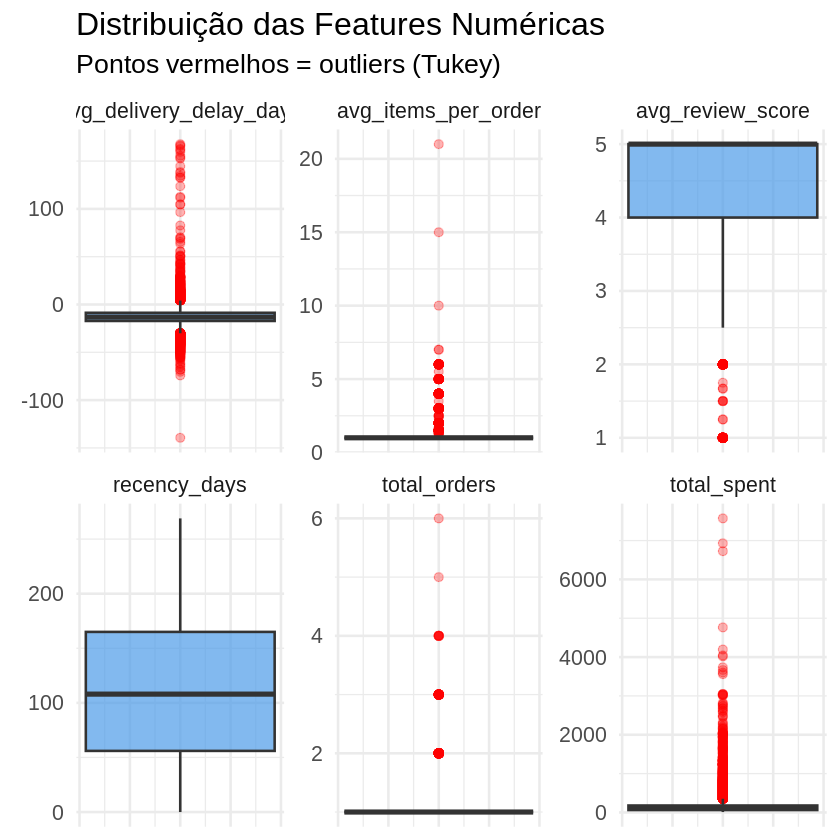

In [ ]:
df_long <- pivot_longer(
  select(df, all_of(features_num)),
  everything(), names_to = "feature", values_to = "valor"
)

ggplot(df_long, aes(y = valor)) +
  geom_boxplot(fill = "#4C9BE8", alpha = 0.7,
               outlier.colour = "red", outlier.alpha = 0.3) +
  facet_wrap(~ feature, scales = "free_y") +
  labs(title    = "Distribuição das Features Numéricas",
       subtitle = "Pontos vermelhos = outliers (Tukey)",
       y = NULL, x = NULL) +
  theme_minimal(base_size = 16) +
  theme(axis.text.x = element_blank(), axis.ticks.x = element_blank())

### 3.4 Coeficiente de Variação

In [ ]:
cv <- sapply(df[, features_num], function(x) round(sd(x) / mean(x) * 100, 1))
print(cv)

           recency_days            total_orders             total_spent 
                   59.2                    18.6                   142.5 
       avg_review_score avg_delivery_delay_days     avg_items_per_order 
                   27.9                   -72.5                    43.9 


### 3.5 Análise de Outliers (Tukey — observacional)

In [ ]:
outliers_summary <- function(x, nome) {
  Q1  <- quantile(x, 0.25)
  Q3  <- quantile(x, 0.75)
  IQR_val <- Q3 - Q1
  lower <- Q1 - 1.5 * IQR_val
  upper <- Q3 + 1.5 * IQR_val
  n_out <- sum(x < lower | x > upper)
  cat(nome, "\n")
  cat("  IQR:", round(IQR_val, 2),
      "| Limite inf:", round(lower, 2),
      "| Limite sup:", round(upper, 2), "\n")
  cat("  N outliers:", n_out, "| %:", round(n_out / length(x) * 100, 1), "%\n\n")
}

for (f in features_num) outliers_summary(df[[f]], f)

recency_days 
  IQR: 109 | Limite inf: -107.5 | Limite sup: 328.5 
  N outliers: 0 | %: 0 %

total_orders 
  IQR: 0 | Limite inf: 1 | Limite sup: 1 
  N outliers: 650 | %: 2.7 %

total_spent 
  IQR: 116.52 | Limite inf: -113.05 | Limite sup: 353.02 
  N outliers: 1934 | %: 8.2 %

avg_review_score 
  IQR: 1 | Limite inf: 2.5 | Limite sup: 6.5 
  N outliers: 2411 | %: 10.2 %

avg_delivery_delay_days 
  IQR: 8.57 | Limite inf: -30.09 | Limite sup: 4.2 
  N outliers: 1108 | %: 4.7 %

avg_items_per_order 
  IQR: 0 | Limite inf: 1 | Limite sup: 1 
  N outliers: 2363 | %: 10 %



### 3.6 Histogramas

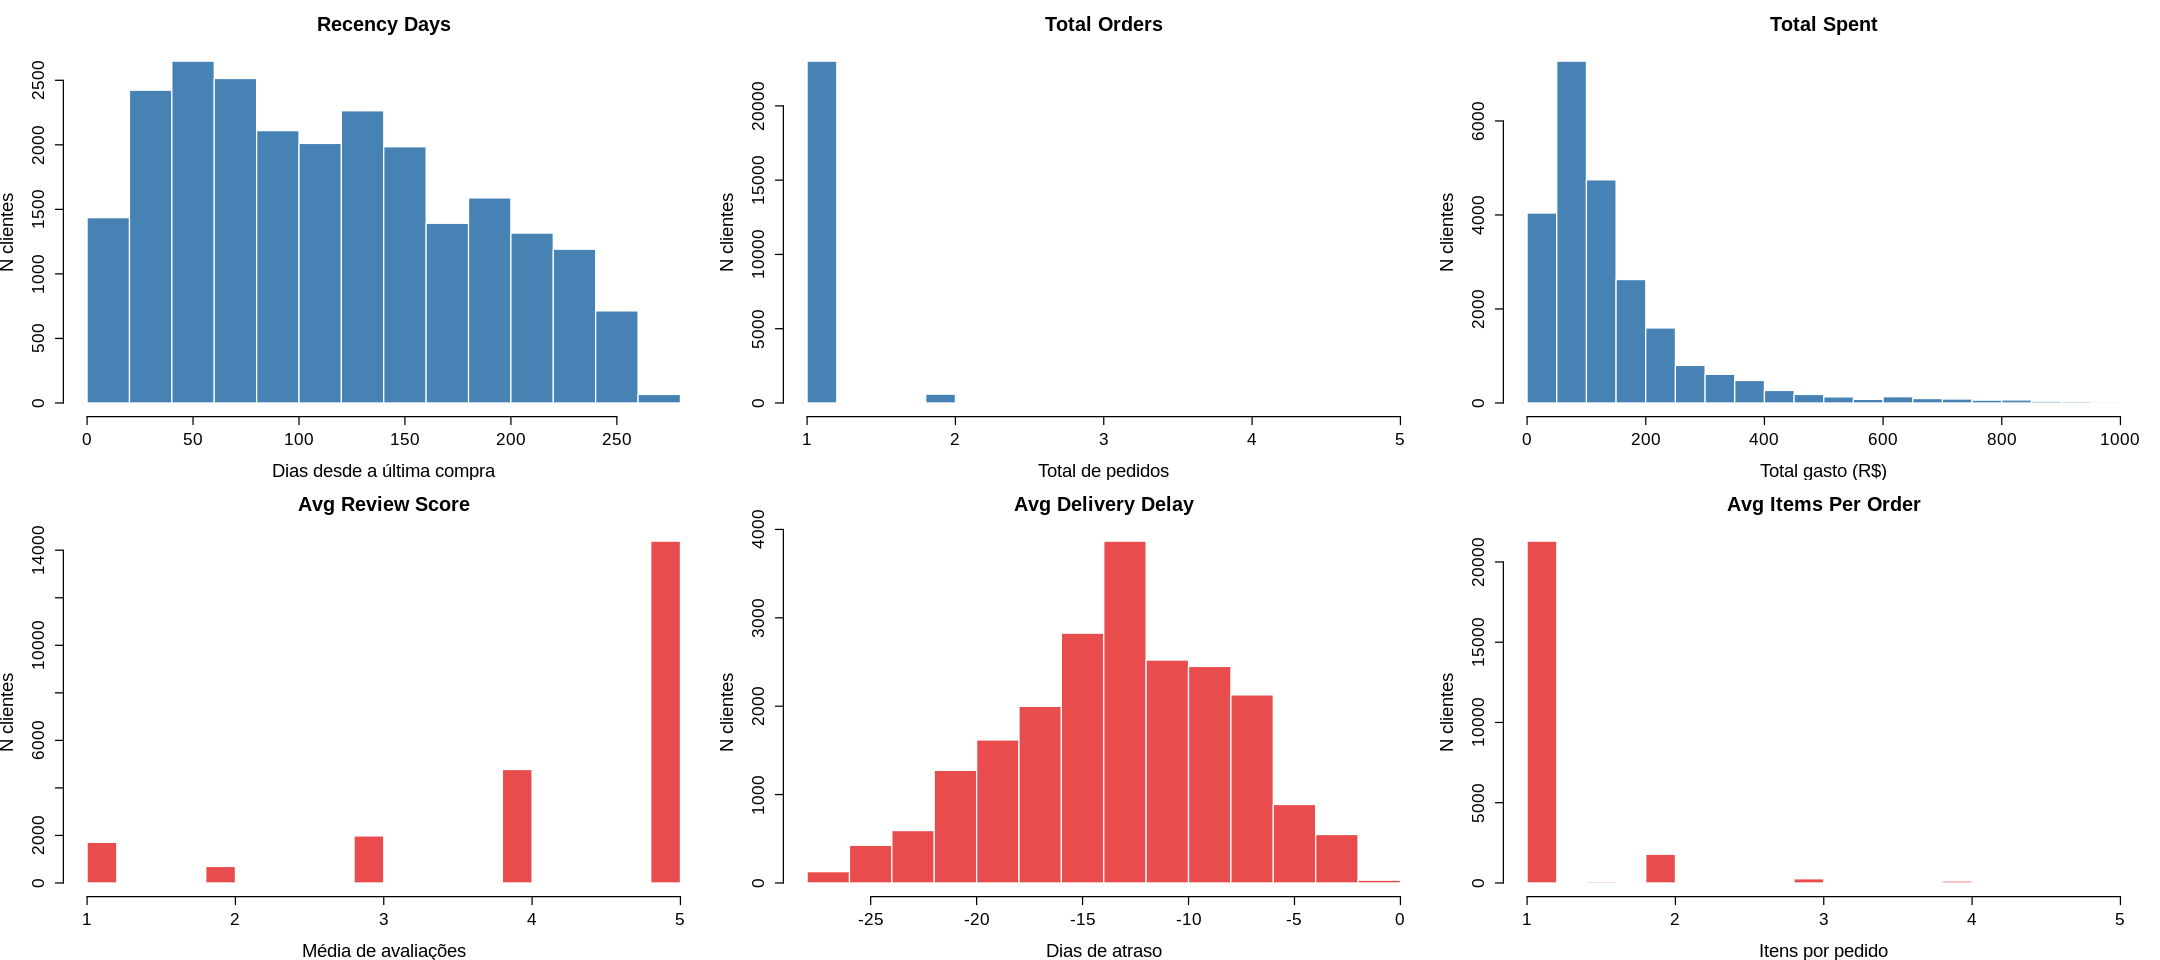

In [ ]:
options(repr.plot.width = 18, repr.plot.height = 8)
par(mfrow = c(2, 3), mar = c(4, 4, 3, 1),
    cex.main = 1.5, cex.lab = 1.4, cex.axis = 1.3)

hist(df$recency_days,
     main = "Recency Days", xlab = "Dias desde a última compra",
     ylab = "N clientes", col = "steelblue", border = "white")

hist(df$total_orders[df$total_orders <= 5],
     main = "Total Orders", xlab = "Total de pedidos",
     ylab = "N clientes", col = "steelblue", border = "white", xlim = c(1, 5))

hist(df$total_spent[df$total_spent <= 1000],
     main = "Total Spent", xlab = "Total gasto (R$)",
     ylab = "N clientes", col = "steelblue", border = "white",
     breaks = seq(0, 1000, by = 50))

hist(df$avg_review_score,
     main = "Avg Review Score", xlab = "Média de avaliações",
     ylab = "N clientes", col = "#E84C4C", border = "white")

hist(df$avg_delivery_delay_days[
       df$avg_delivery_delay_days >= quantile(df$avg_delivery_delay_days, 0.05) &
       df$avg_delivery_delay_days <= quantile(df$avg_delivery_delay_days, 0.95)],
     main = "Avg Delivery Delay", xlab = "Dias de atraso",
     ylab = "N clientes", col = "#E84C4C", border = "white")

hist(df$avg_items_per_order[df$avg_items_per_order <= 5],
     main = "Avg Items Per Order", xlab = "Itens por pedido",
     ylab = "N clientes", col = "#E84C4C", border = "white", xlim = c(1, 5))

### 3.7 Comparação por Grupo Target

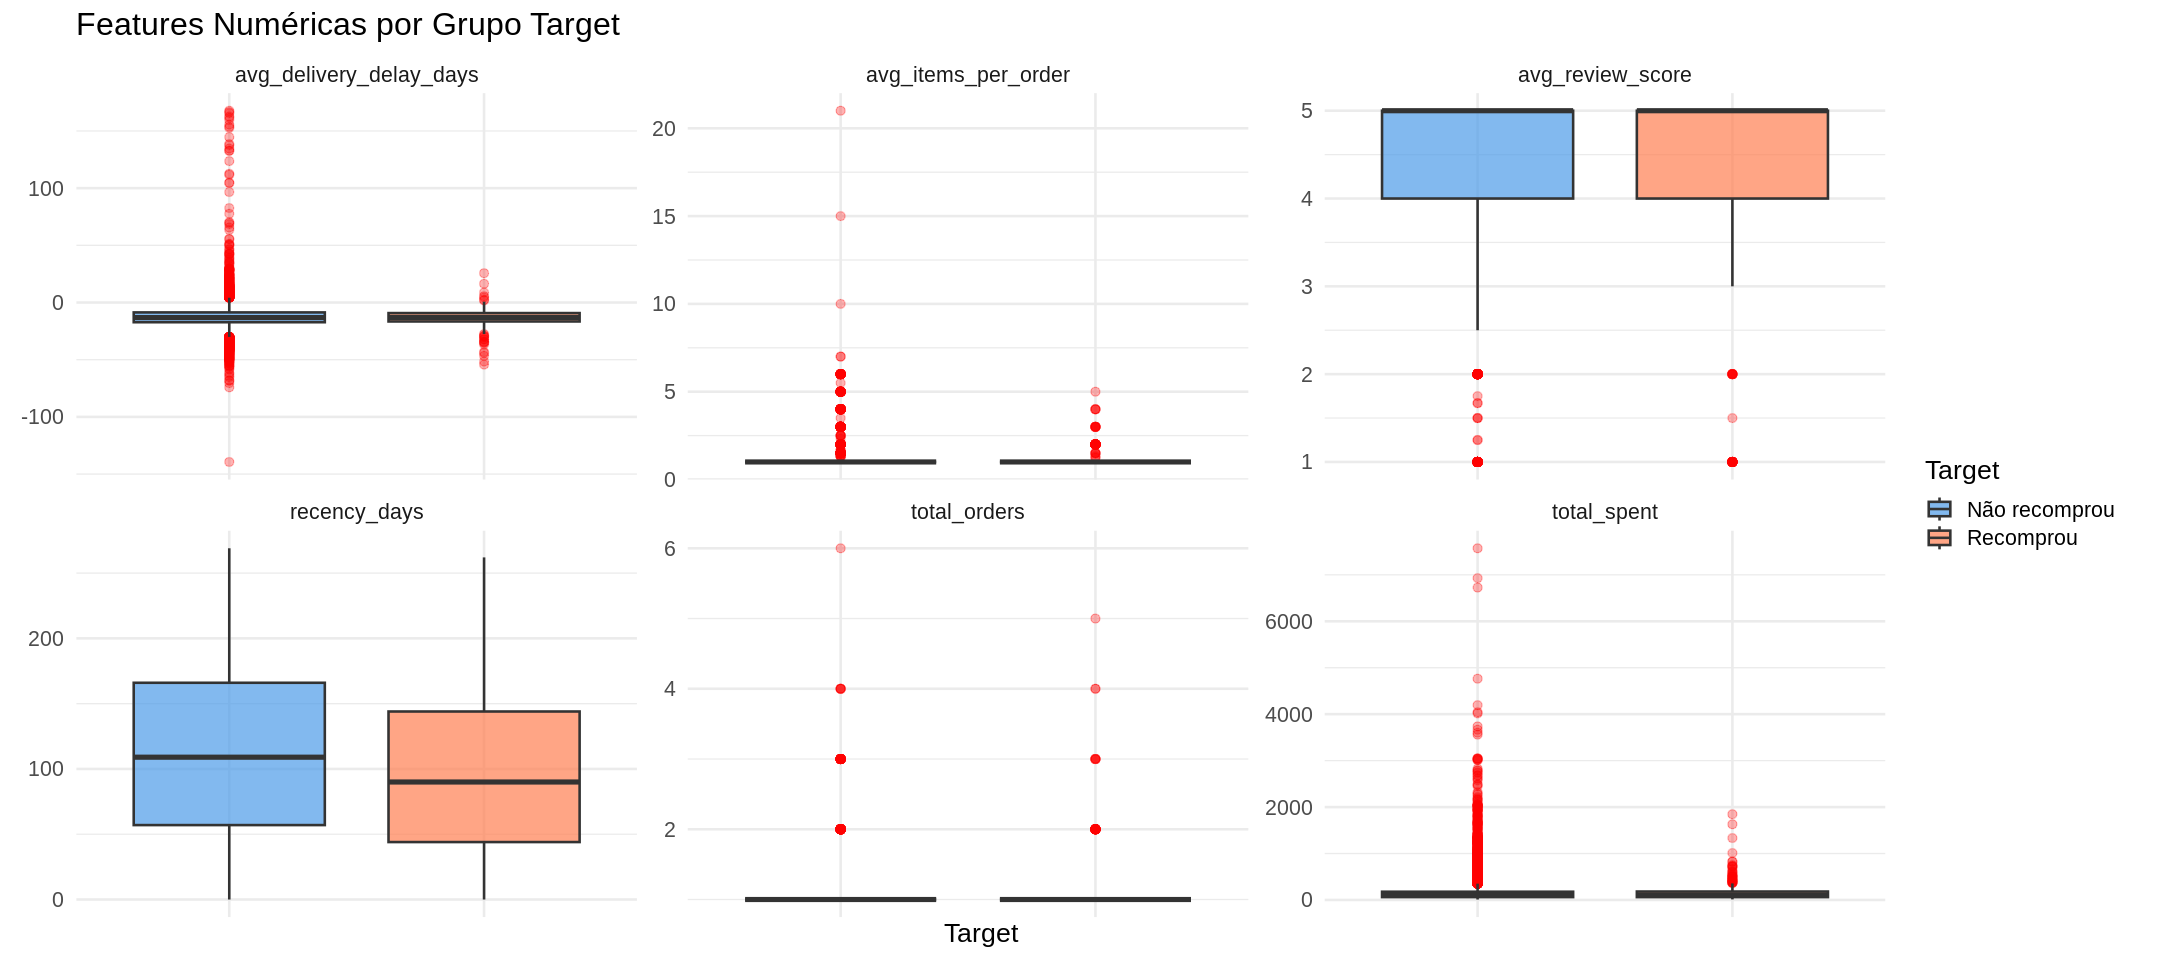

In [ ]:
df_long_target <- pivot_longer(
  select(df, all_of(features_num), target_repurchase),
  cols = all_of(features_num), names_to = "feature", values_to = "valor"
)

ggplot(df_long_target, aes(x = factor(target_repurchase), y = valor,
                           fill = factor(target_repurchase))) +
  geom_boxplot(alpha = 0.7, outlier.colour = "red", outlier.alpha = 0.3) +
  facet_wrap(~ feature, scales = "free_y", ncol = 3) +
  scale_fill_manual(values = c("Nao_recomprou" = "#4C9BE8", "Recomprou" = "coral"),
                    labels  = c("Nao_recomprou" = "Não recomprou", "Recomprou" = "Recomprou")) +
  labs(title = "Features Numéricas por Grupo Target",
       x = "Target", y = NULL, fill = "Target") +
  theme_minimal(base_size = 16) +
  theme(axis.text.x = element_blank(), axis.ticks.x = element_blank())

### 3.8 Teste de Wilcoxon

In [ ]:
estatisticas_por_grupo <- function(feature) {
  grupo_nao <- df[[feature]][df$target_repurchase == "Nao_recomprou"]
  grupo_sim <- df[[feature]][df$target_repurchase == "Recomprou"]
  p_value   <- wilcox.test(df[[feature]] ~ df$target_repurchase)$p.value
  data.frame(
    feature       = feature,
    media_nao     = round(mean(grupo_nao), 2),
    media_sim     = round(mean(grupo_sim), 2),
    p_value       = round(p_value, 4),
    significativo = ifelse(p_value < 0.05, "Sim", "Nao")
  )
}

tabela_estatistica <- do.call(rbind, lapply(features_num, estatisticas_por_grupo))
print(tabela_estatistica)

                  feature media_nao media_sim p_value significativo
1            recency_days    114.51     99.99  0.0000           Sim
2            total_orders      1.03      1.10  0.0000           Sim
3             total_spent    163.43    153.79  0.8446           Nao
4        avg_review_score      4.24      4.41  0.0019           Sim
5 avg_delivery_delay_days    -13.00    -13.49  0.8515           Nao
6     avg_items_per_order      1.13      1.17  0.0023           Sim


### 3.9 Matriz de Correlação



Table: Correlação Spearman — Todas as Numéricas

|                        | recency_days| total_orders| total_spent| avg_review_score| avg_delivery_delay_days| avg_items_per_order|
|:-----------------------|------------:|------------:|-----------:|----------------:|-----------------------:|-------------------:|
|recency_days            |         1.00|        -0.05|       -0.01|            -0.04|                   -0.25|                0.00|
|total_orders            |        -0.05|         1.00|        0.15|            -0.02|                   -0.02|                0.07|
|total_spent             |        -0.01|         0.15|        1.00|            -0.01|                   -0.04|                0.22|
|avg_review_score        |        -0.04|        -0.02|       -0.01|             1.00|                   -0.11|               -0.07|
|avg_delivery_delay_days |        -0.25|        -0.02|       -0.04|            -0.11|                    1.00|               -0.04|
|avg_items_per_order     

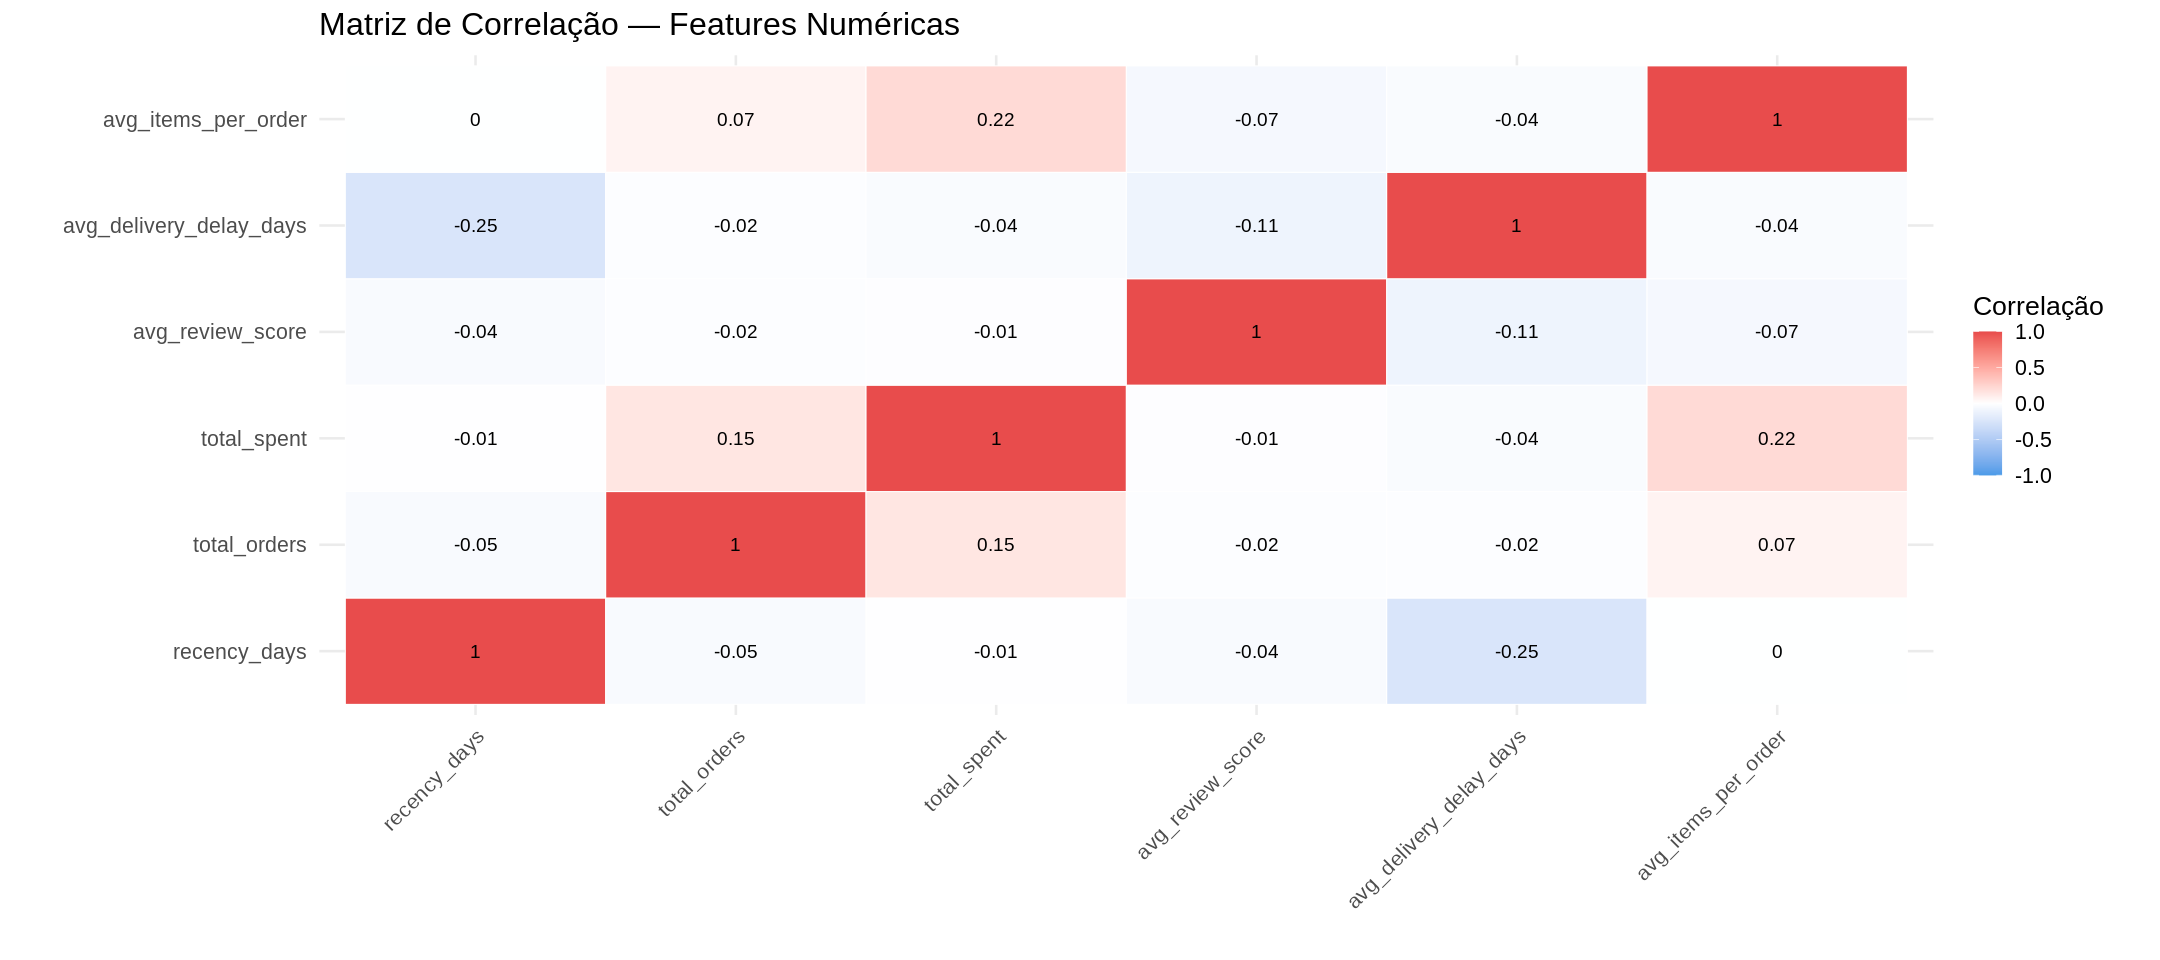

In [ ]:
cor_matrix <- cor(df[, features_num], method = "spearman")
cor_melted  <- melt(cor_matrix)

ggplot(cor_melted, aes(x = Var1, y = Var2, fill = value)) +
  geom_tile(colour = "white") +
  geom_text(aes(label = round(value, 2)), size = 4) +
  scale_fill_gradient2(low = "#4C9BE8", mid = "white", high = "#E84C4C",
                       midpoint = 0, limits = c(-1, 1)) +
  labs(title = "Matriz de Correlação — Features Numéricas",
       x = NULL, y = NULL, fill = "Correlação") +
  theme_minimal(base_size = 16) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

kable(round(cor_matrix, 2), caption = "Correlação Spearman — Todas as Numéricas")

## 4. Preparação dos Dados

### 4.1 Divisão Treino / Teste (70/30)

In [ ]:
set.seed(811)
indices <- createDataPartition(df$target_repurchase, p = 0.70, list = FALSE)
treino  <- df[indices, ]
teste   <- df[-indices, ]

cat("Treino:", nrow(treino), "linhas\n")
cat("Teste: ", nrow(teste),  "linhas\n\n")

cat("Proporção target — Treino:\n")
print(round(prop.table(table(treino$target_repurchase)) * 100, 2))

cat("\nProporção target — Teste:\n")
print(round(prop.table(table(teste$target_repurchase)) * 100, 2))

treino_antes <- treino

Treino: 16562 linhas
Teste:  7096 linhas

Proporção target — Treino:

Nao_recomprou     Recomprou 
        97.66          2.34 

Proporção target — Teste:

Nao_recomprou     Recomprou 
        97.67          2.33 


### 4.2 Verificação de Sobreposição

In [ ]:
linhas_comuns <- intersect(rownames(treino), rownames(teste))
cat("Linhas em comum entre treino e teste:", length(linhas_comuns), "\n")

Linhas em comum entre treino e teste: 0 


### 4.3 Remoção de Outliers

In [ ]:
tukey_limites_safe <- function(x, nome = "") {
  Q1      <- quantile(x, 0.25)
  Q3      <- quantile(x, 0.75)
  IQR_val <- Q3 - Q1
  if (IQR_val == 0) {
    lower <- quantile(x, 0.01)
    upper <- quantile(x, 0.99)
    cat("AVISO: IQR=0 em '", nome, "' usando p1/p99: [",
        round(lower, 2), ",", round(upper, 2), "]\n", sep = "")
  } else {
    lower <- Q1 - 1.5 * IQR_val
    upper <- Q3 + 1.5 * IQR_val
  }
  list(lower = lower, upper = upper)
}

features_num_out <- c("recency_days", "total_orders", "total_spent",
                      "avg_review_score", "avg_delivery_delay_days",
                      "avg_items_per_order")

limites <- lapply(features_num_out, function(f) tukey_limites_safe(treino[[f]], f))
names(limites) <- features_num_out

for (f in features_num_out) {
  treino <- treino[
    treino[[f]] >= limites[[f]]$lower &
    treino[[f]] <= limites[[f]]$upper, ]
}

cat("Treino antes da remoção:", nrow(treino_antes), "\n")
cat("Treino após remoção:    ", nrow(treino), "\n")
cat("Clientes removidos:     ", nrow(treino_antes) - nrow(treino),
    "(", round((nrow(treino_antes) - nrow(treino)) / nrow(treino_antes) * 100, 1), "%)\n\n")
cat("Teste mantido intacto: ", nrow(teste), "clientes\n\n")

for (f in features_num_out) {
  cat(f, "limite inf:", round(limites[[f]]$lower, 2),
      "| sup:", round(limites[[f]]$upper, 2), "\n")
}

AVISO: IQR=0 em 'total_orders' usando p1/p99: [1,2]
AVISO: IQR=0 em 'avg_items_per_order' usando p1/p99: [1,3]
Treino antes da remoção: 16562 
Treino após remoção:     13107 
Clientes removidos:      3455 ( 20.9 %)

Teste mantido intacto:  7096 clientes

recency_days limite inf: -109 | sup: 331 
total_orders limite inf: 1 | sup: 2 
total_spent limite inf: -111.01 | sup: 348.9 
avg_review_score limite inf: 2.5 | sup: 6.5 
avg_delivery_delay_days limite inf: -29.83 | sup: 3.81 
avg_items_per_order limite inf: 1 | sup: 3 


### 4.4 Distribuição do Treino — Antes da Remoção

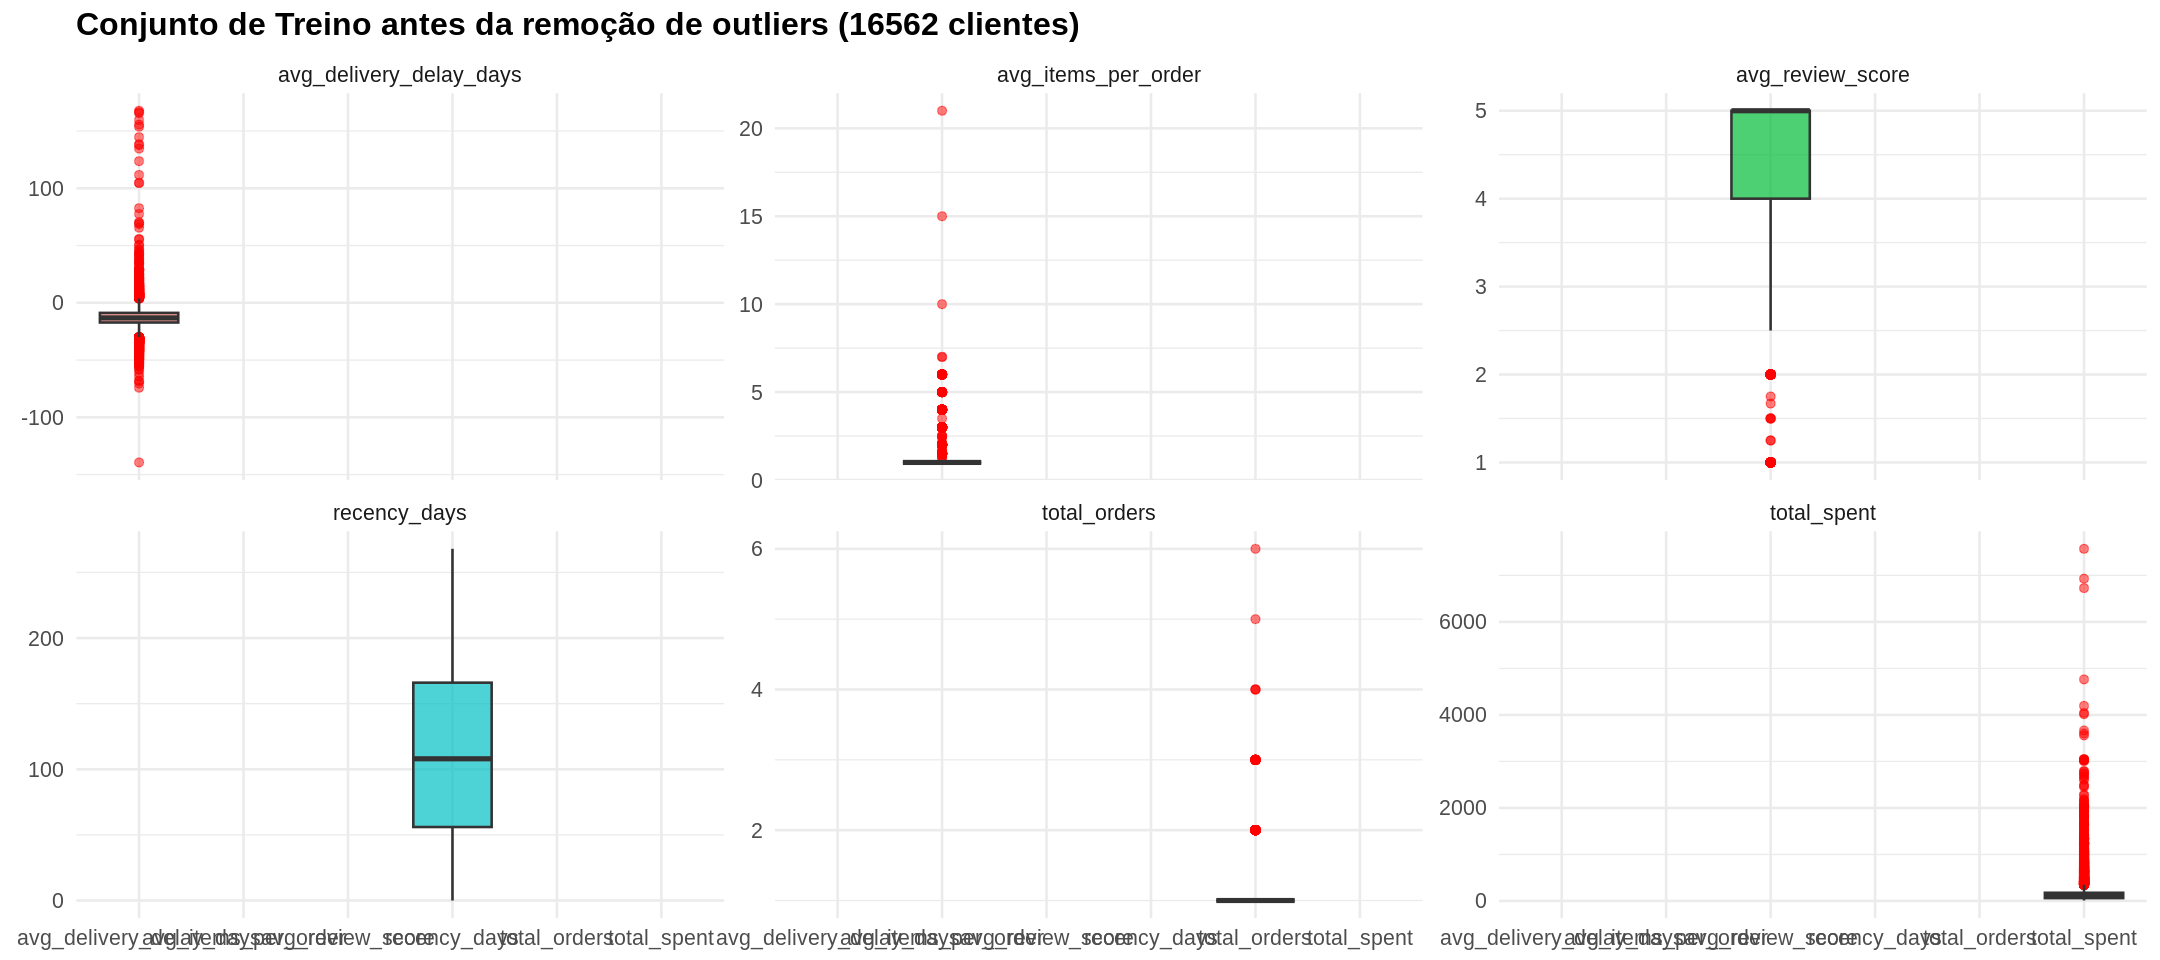

In [ ]:
treino_antes %>%
  pivot_longer(cols = all_of(features_num_out),
               names_to = "feature", values_to = "valor") %>%
  ggplot(aes(x = feature, y = valor, fill = feature)) +
  geom_boxplot(alpha = 0.7, outlier.colour = "red", outlier.alpha = 0.5) +
  facet_wrap(~ feature, scales = "free_y") +
  labs(title = paste0("Conjunto de Treino antes da remoção de outliers (",
                      nrow(treino_antes), " clientes)"),
       x = NULL, y = NULL) +
  theme_minimal(base_size = 16) +
  theme(plot.title = element_text(face = "bold"), legend.position = "none")

### 4.5 Distribuição do Treino — Após Remoção

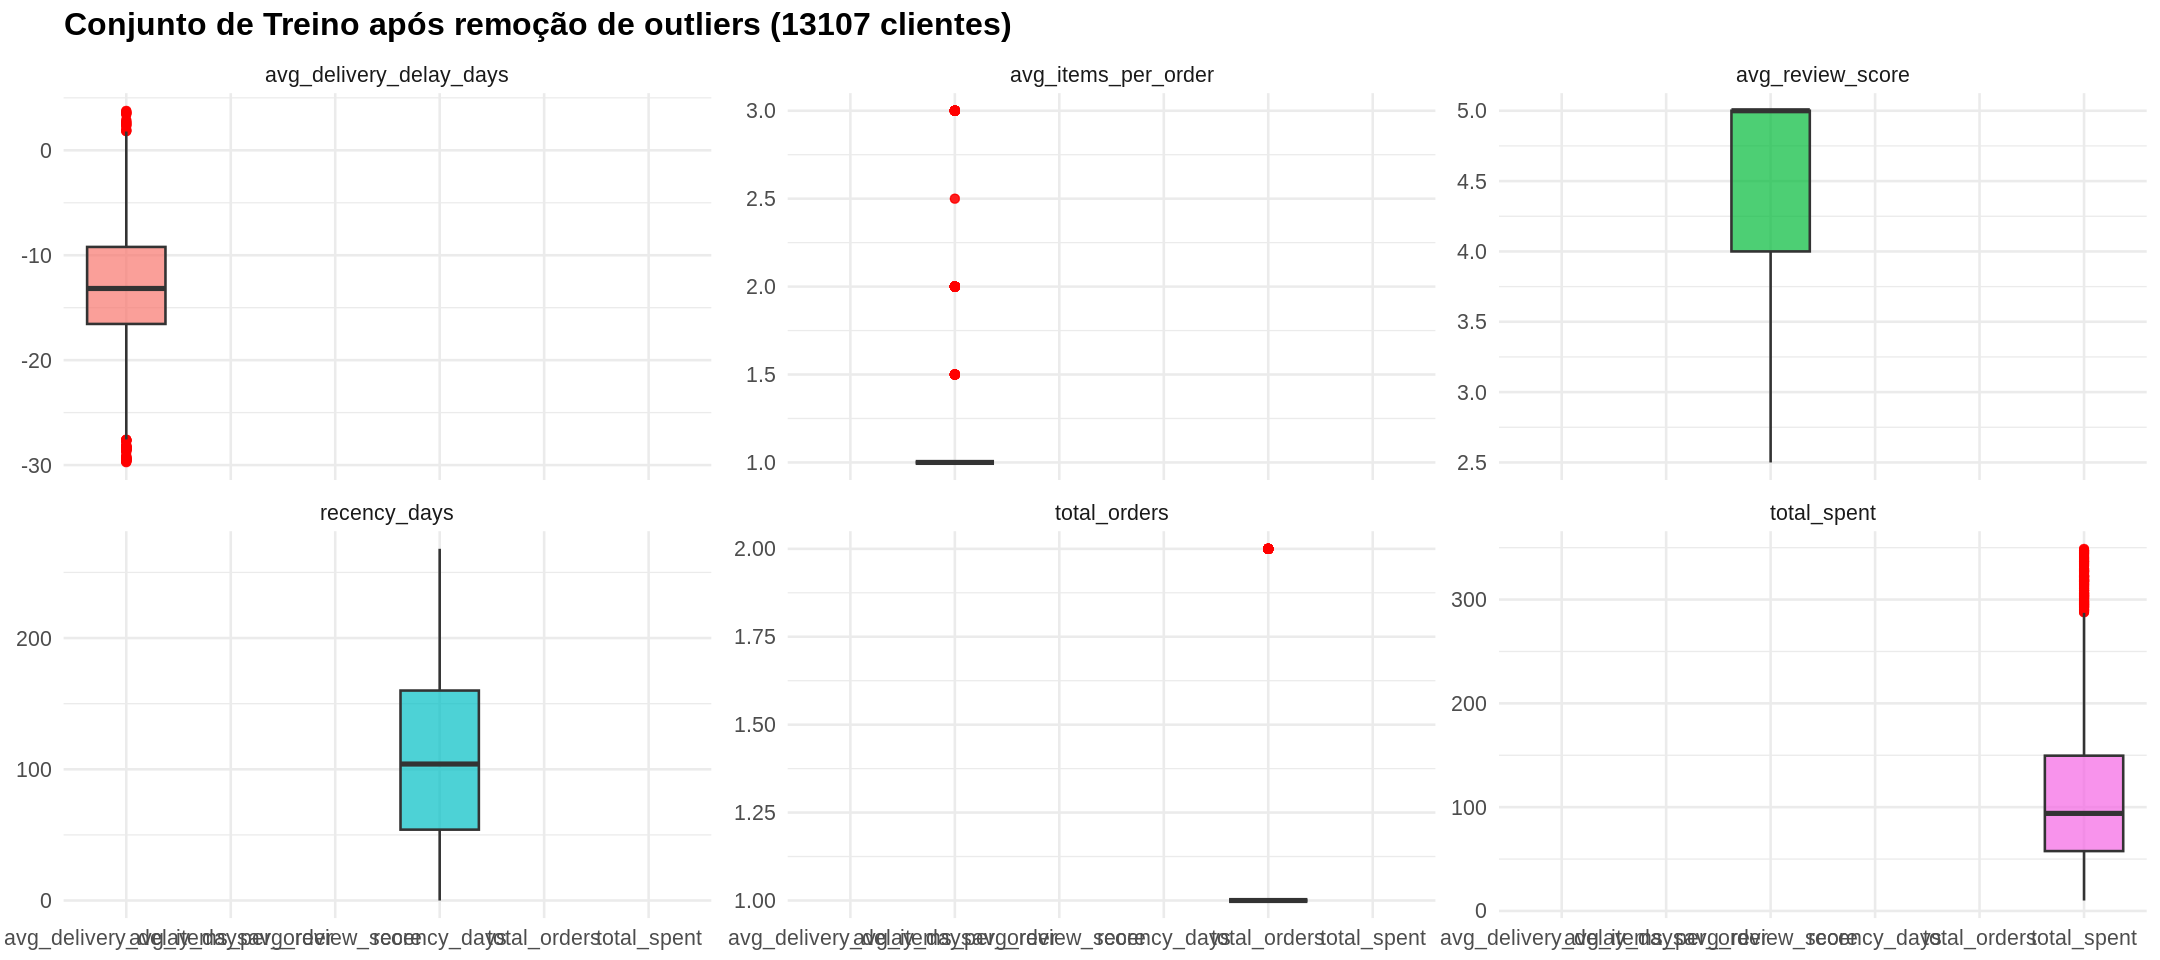

In [ ]:
treino %>%
  pivot_longer(cols = all_of(features_num_out),
               names_to = "feature", values_to = "valor") %>%
  ggplot(aes(x = feature, y = valor, fill = feature)) +
  geom_boxplot(alpha = 0.7, outlier.colour = "red", outlier.alpha = 0.5) +
  facet_wrap(~ feature, scales = "free_y") +
  labs(title = paste0("Conjunto de Treino após remoção de outliers (",
                      nrow(treino), " clientes)"),
       x = NULL, y = NULL) +
  theme_minimal(base_size = 16) +
  theme(plot.title = element_text(face = "bold"), legend.position = "none")

### 4.6 Correlação no Treino



Table: Correlação Spearman — Treino

|                        | recency_days| total_orders| total_spent| avg_review_score| avg_delivery_delay_days| avg_items_per_order|
|:-----------------------|------------:|------------:|-----------:|----------------:|-----------------------:|-------------------:|
|recency_days            |         1.00|        -0.03|       -0.01|            -0.03|                   -0.24|               -0.02|
|total_orders            |        -0.03|         1.00|        0.12|            -0.03|                   -0.01|                0.04|
|total_spent             |        -0.01|         0.12|        1.00|            -0.01|                   -0.03|                0.17|
|avg_review_score        |        -0.03|        -0.03|       -0.01|             1.00|                   -0.06|                0.00|
|avg_delivery_delay_days |        -0.24|        -0.01|       -0.03|            -0.06|                    1.00|               -0.03|
|avg_items_per_order     |        -0.

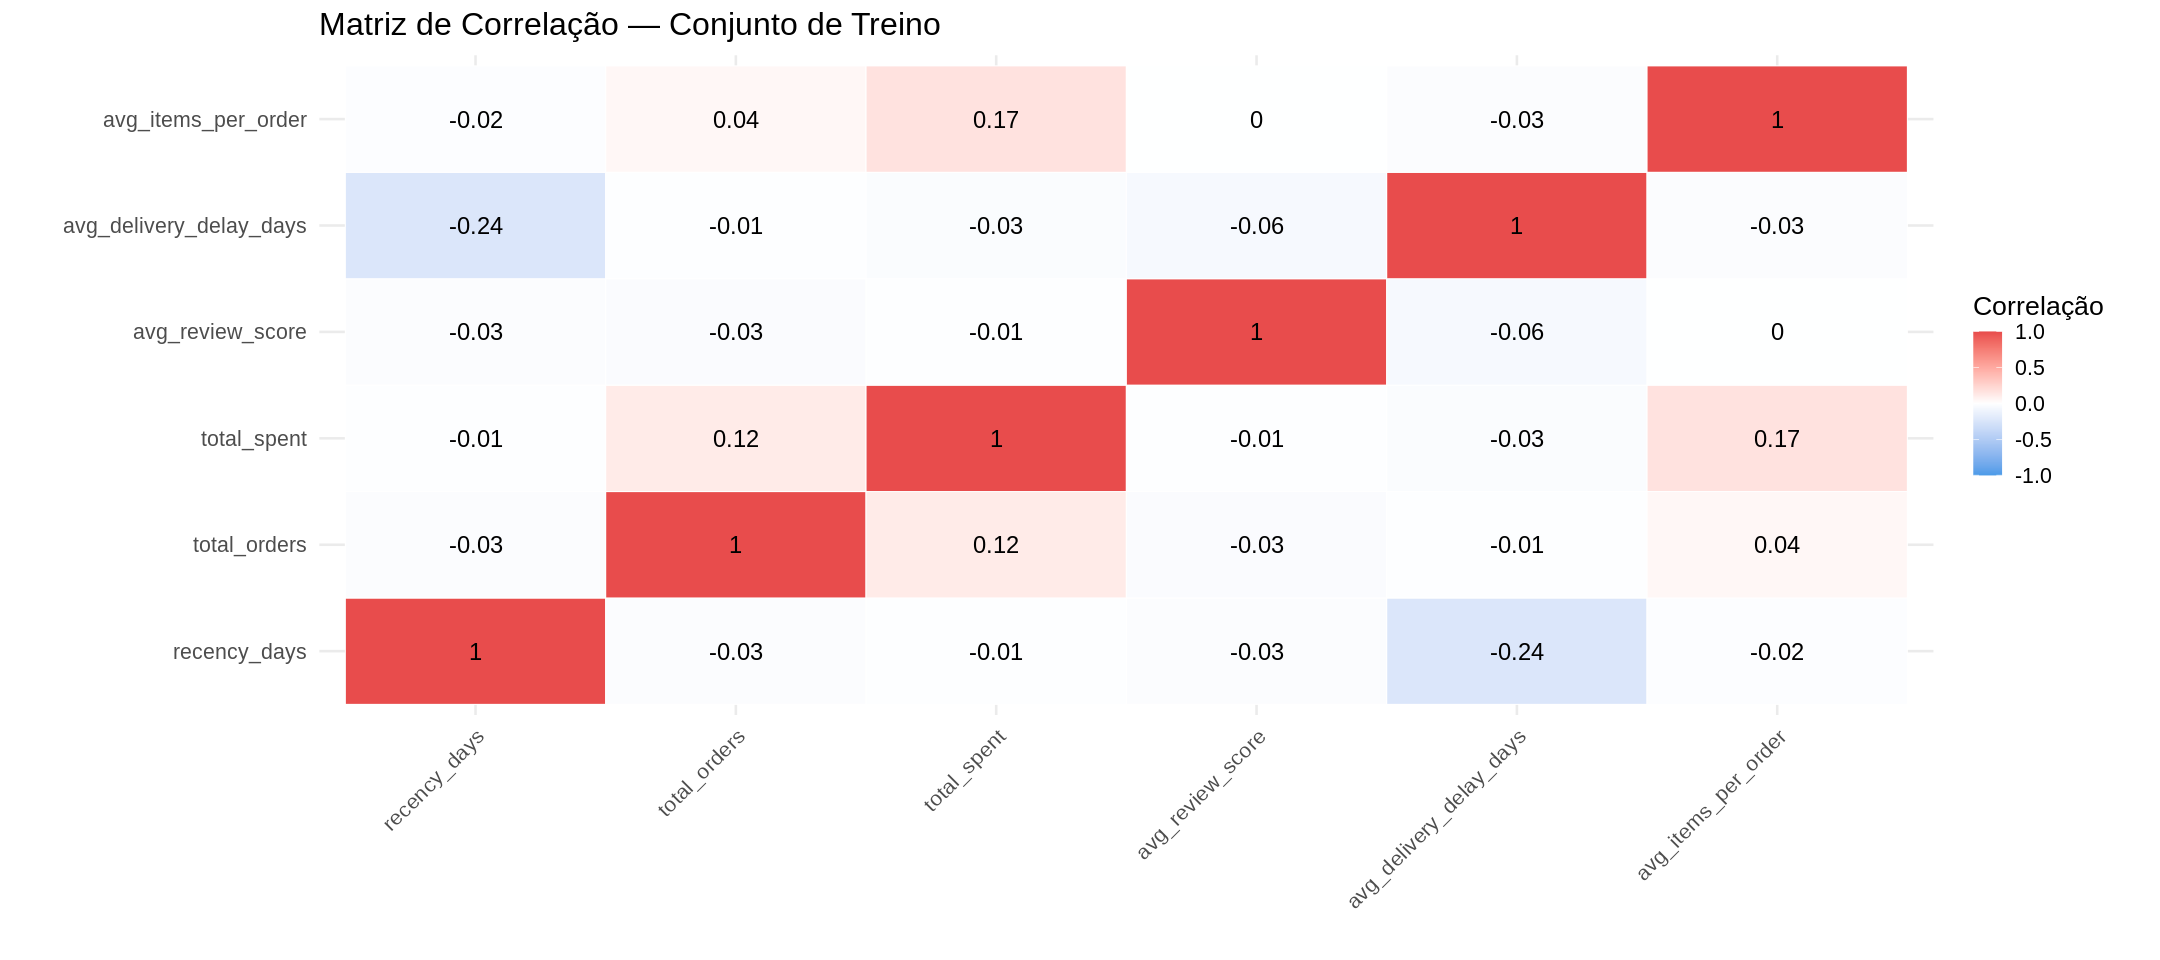

In [ ]:
features_num_treino <- c("recency_days", "total_orders", "total_spent",
                          "avg_review_score", "avg_delivery_delay_days",
                          "avg_items_per_order")

features_cor <- features_num_treino[sapply(treino[, features_num_treino],
                                            function(x) sd(x) > 0)]

if (length(features_num_treino) != length(features_cor)) {
  excluidas <- setdiff(features_num_treino, features_cor)
  cat("Variáveis com variância zero (excluídas):",
      paste(excluidas, collapse = ", "), "\n\n")
}

cor_matrix_treino <- cor(treino[, features_cor], method = "spearman")
cor_melted_treino <- melt(cor_matrix_treino)

ggplot(cor_melted_treino, aes(x = Var1, y = Var2, fill = value)) +
  geom_tile(colour = "white") +
  geom_text(aes(label = round(value, 2)), size = 5) +
  scale_fill_gradient2(low = "#4C9BE8", mid = "white", high = "#E84C4C",
                       midpoint = 0, limits = c(-1, 1)) +
  labs(title = "Matriz de Correlação — Conjunto de Treino",
       x = NULL, y = NULL, fill = "Correlação") +
  theme_minimal(base_size = 16) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

kable(round(cor_matrix_treino, 2), caption = "Correlação Spearman — Treino")

### 4.7 Feature Selection — Importância via Random Forest

                                              feature importance
total_spent                               total_spent 117.172777
avg_delivery_delay_days       avg_delivery_delay_days 114.142566
recency_days                             recency_days  87.732698
avg_review_score                     avg_review_score  14.078589
state_sp                                     state_sp   6.729800
avg_items_per_order               avg_items_per_order   6.391715
state_outros                             state_outros   5.828718
cat_outros                                 cat_outros   5.599573
cat_cama_mesa_banho               cat_cama_mesa_banho   5.369109
cat_esporte_lazer                   cat_esporte_lazer   5.159114
state_mg                                     state_mg   5.102369
state_rj                                     state_rj   4.808191
cat_moveis_decoracao             cat_moveis_decoracao   4.285818
cat_beleza_saude                     cat_beleza_saude   3.889135
cat_informatica_acessorio

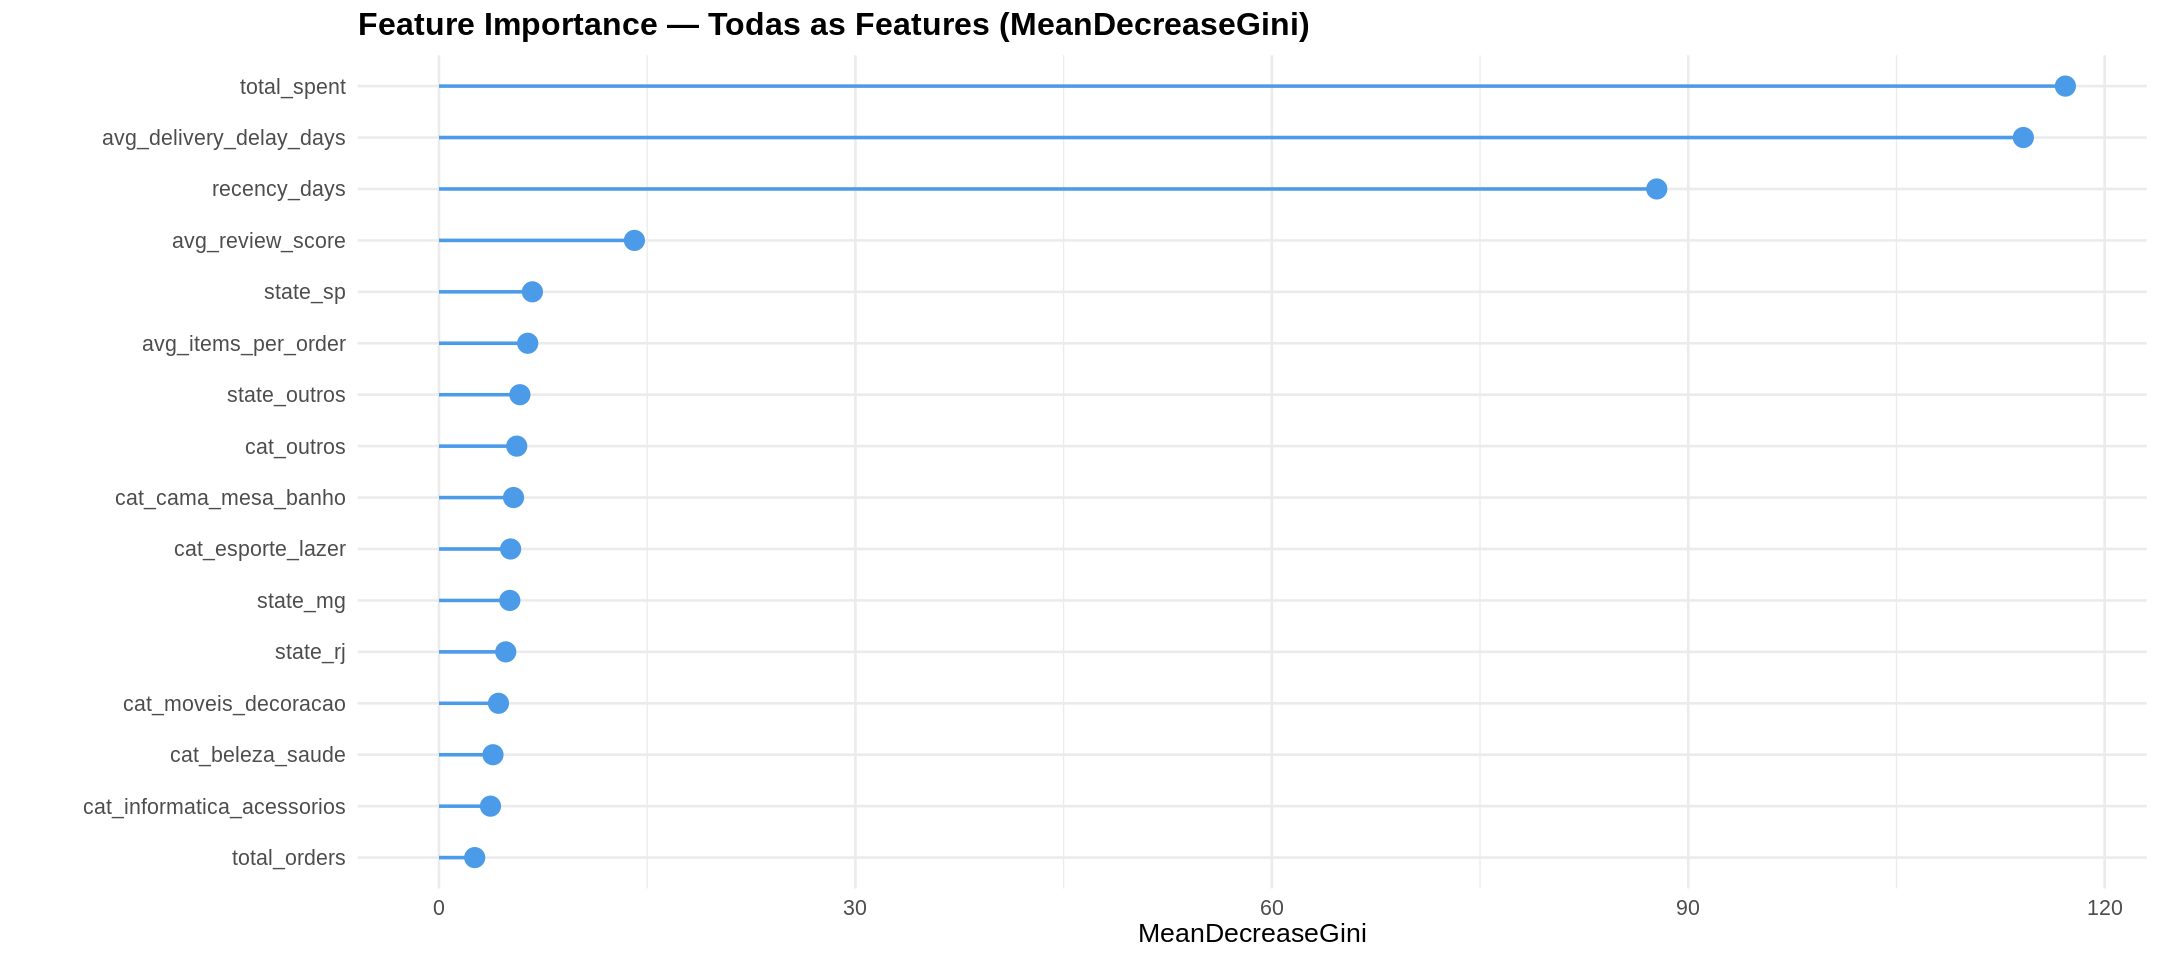

In [ ]:
set.seed(811)
rf_selection <- randomForest(target_repurchase ~ ., data = treino,
                              ntree = 200, importance = TRUE)

importance_df <- data.frame(
  feature    = rownames(importance(rf_selection)),
  importance = importance(rf_selection)[, "MeanDecreaseGini"]
)
importance_df <- importance_df[order(importance_df$importance, decreasing = TRUE), ]
print(importance_df)

ggplot(importance_df, aes(x = importance, y = reorder(feature, importance))) +
  geom_point(size = 5, color = "#4C9BE8") +
  geom_segment(aes(x = 0, xend = importance,
                   y = reorder(feature, importance),
                   yend = reorder(feature, importance)),
               color = "#4C9BE8", linewidth = 1) +
  labs(title = "Feature Importance — Todas as Features (MeanDecreaseGini)",
       x = "MeanDecreaseGini", y = NULL) +
  theme_minimal(base_size = 16) +
  theme(plot.title = element_text(face = "bold"))

### 4.8 Comparação OOB com e sem Features Binárias

In [ ]:
features_bin <- c("cat_cama_mesa_banho", "cat_esporte_lazer",
                  "cat_beleza_saude", "cat_moveis_decoracao",
                  "cat_informatica_acessorios", "cat_outros",
                  "state_sp", "state_rj", "state_mg", "state_outros")

rf_num <- randomForest(
  target_repurchase ~ recency_days + total_orders + total_spent +
                      avg_review_score + avg_delivery_delay_days +
                      avg_items_per_order,
  data = treino, ntree = 200
)

rf_all <- randomForest(target_repurchase ~ ., data = treino, ntree = 200)

cat("OOB Error — só numéricas:", round(rf_num$err.rate[200, "OOB"], 4), "\n")
cat("OOB Error — todas:       ", round(rf_all$err.rate[200, "OOB"], 4), "\n")

OOB Error — só numéricas: 0.025 
OOB Error — todas:        0.025 


### 4.9 Seleção Final de Features e Class Weights

In [ ]:
features_finais <- c("recency_days", "total_orders", "total_spent",
                     "avg_review_score", "avg_delivery_delay_days",
                     "avg_items_per_order")

treino_final <- treino[, c(features_finais, "target_repurchase")]
teste_final  <- teste[,  c(features_finais, "target_repurchase")]

cat("Treino final:", nrow(treino_final), "clientes\n")
cat("Teste final: ", nrow(teste_final),  "clientes\n\n")

print(table(treino_final$target_repurchase))

n_nao  <- sum(treino_final$target_repurchase == "Nao_recomprou")
n_sim  <- sum(treino_final$target_repurchase == "Recomprou")
ratio  <- n_nao / n_sim

cat("\nPeso aplicado a Recomprou:", round(ratio, 1), "x\n")

pesos_treino <- ifelse(treino_final$target_repurchase == "Recomprou", ratio, 1)

Treino final: 13107 clientes
Teste final:  7096 clientes


Nao_recomprou     Recomprou 
        12779           328 

Peso aplicado a Recomprou: 39 x


### 4.10 Correlação no Treino Final



Table: Correlação Spearman — Treino Final

|                        | recency_days| total_orders| total_spent| avg_review_score| avg_delivery_delay_days| avg_items_per_order|
|:-----------------------|------------:|------------:|-----------:|----------------:|-----------------------:|-------------------:|
|recency_days            |         1.00|        -0.03|       -0.01|            -0.03|                   -0.24|               -0.02|
|total_orders            |        -0.03|         1.00|        0.12|            -0.03|                   -0.01|                0.04|
|total_spent             |        -0.01|         0.12|        1.00|            -0.01|                   -0.03|                0.17|
|avg_review_score        |        -0.03|        -0.03|       -0.01|             1.00|                   -0.06|                0.00|
|avg_delivery_delay_days |        -0.24|        -0.01|       -0.03|            -0.06|                    1.00|               -0.03|
|avg_items_per_order     |     

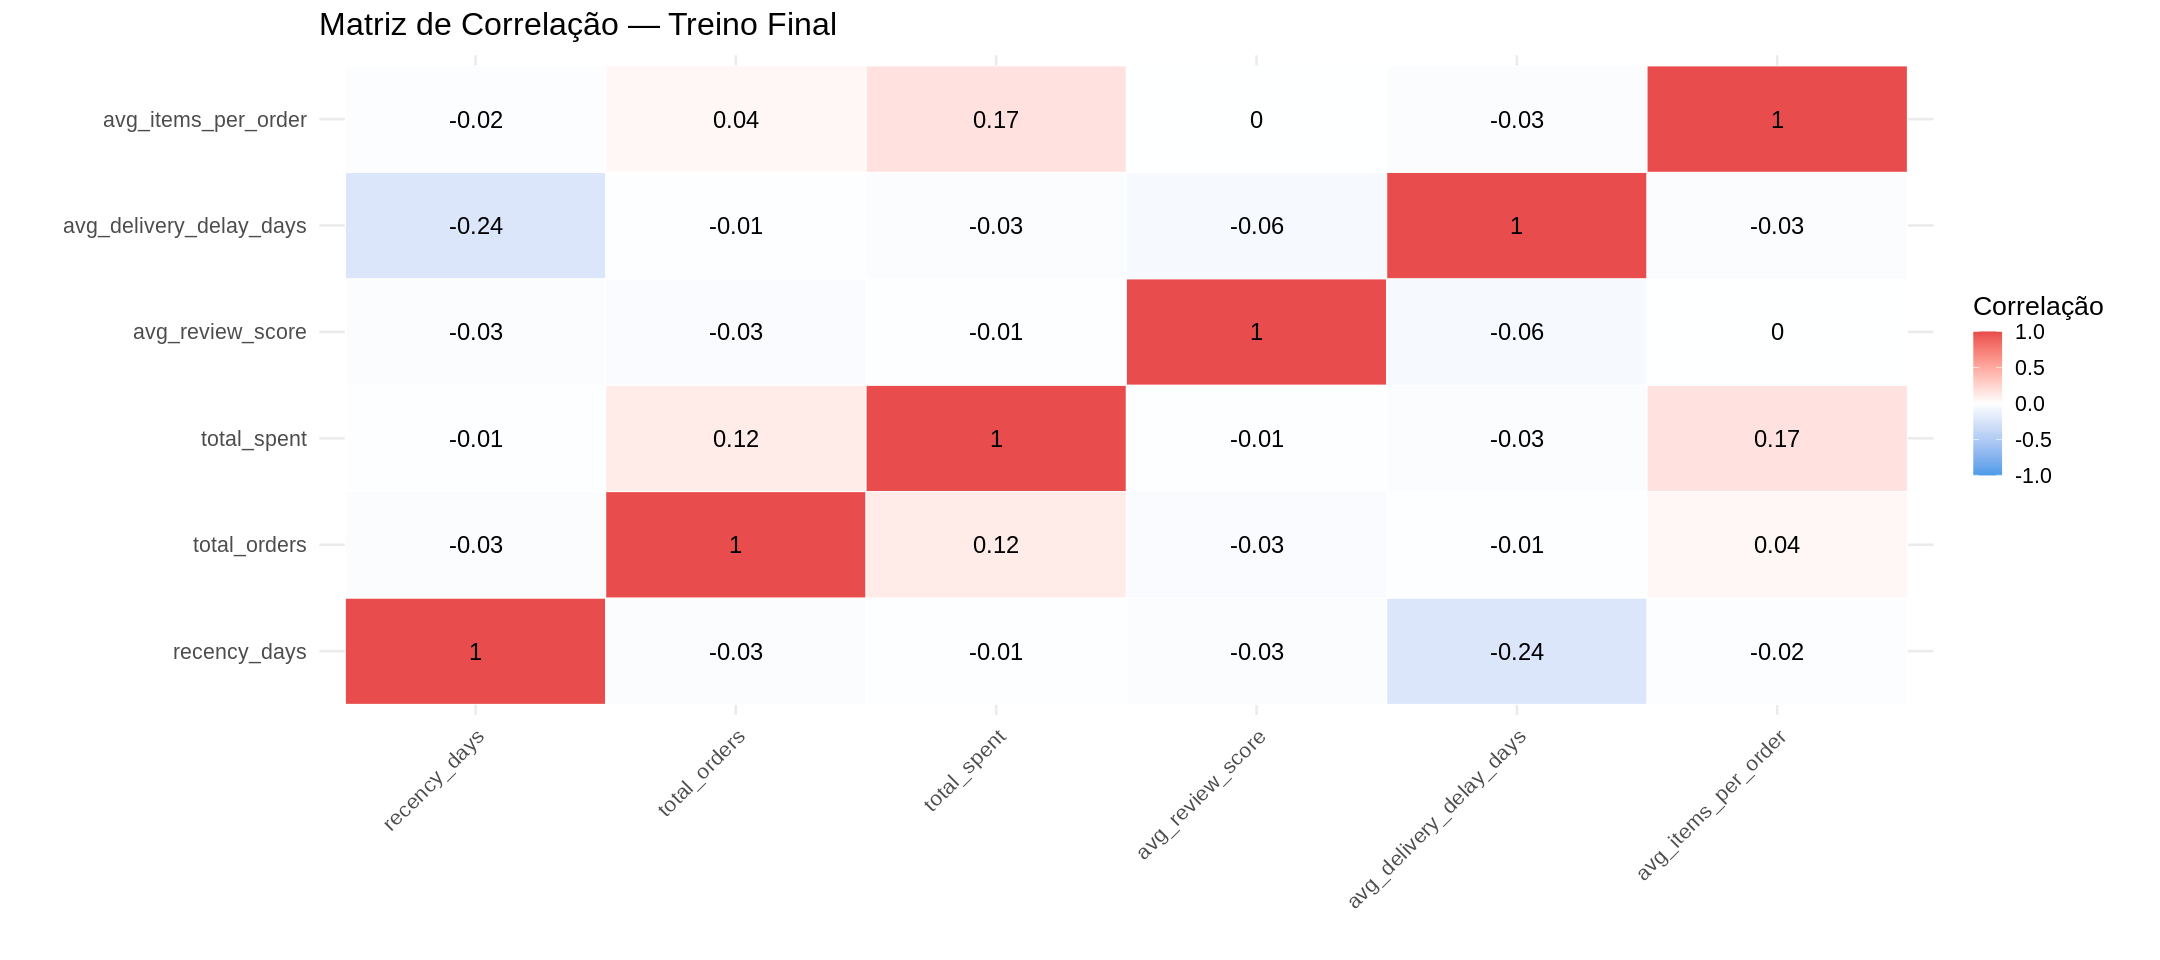

In [ ]:
features_cor_b <- features_finais[sapply(treino_final[, features_finais],
                                          function(x) sd(x) > 0)]

if (length(features_finais) != length(features_cor_b)) {
  excluidas <- setdiff(features_finais, features_cor_b)
  cat("Variáveis excluídas (variância zero):", paste(excluidas, collapse = ", "), "\n\n")
}

cor_final        <- cor(treino_final[, features_cor_b], method = "spearman")
cor_melted_final <- melt(cor_final)

ggplot(cor_melted_final, aes(x = Var1, y = Var2, fill = value)) +
  geom_tile(colour = "white") +
  geom_text(aes(label = round(value, 2)), size = 5) +
  scale_fill_gradient2(low = "#4C9BE8", mid = "white", high = "#E84C4C",
                       midpoint = 0, limits = c(-1, 1)) +
  labs(title = "Matriz de Correlação — Treino Final",
       x = NULL, y = NULL, fill = "Correlação") +
  theme_minimal(base_size = 16) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

kable(round(cor_final, 2), caption = "Correlação Spearman — Treino Final")

## 5. Baseline Ingênua

In [ ]:
baseline <- rep("Nao_recomprou", nrow(teste_final))
baseline <- factor(baseline, levels = levels(teste_final$target_repurchase))

cm_base <- confusionMatrix(baseline, teste_final$target_repurchase,
                            positive = "Recomprou")
print(cm_base)

baseline_pr <- mean(teste_final$target_repurchase == "Recomprou")

Confusion Matrix and Statistics

               Reference
Prediction      Nao_recomprou Recomprou
  Nao_recomprou          6931       165
  Recomprou                 0         0
                                         
               Accuracy : 0.9767         
                 95% CI : (0.973, 0.9801)
    No Information Rate : 0.9767         
    P-Value [Acc > NIR] : 0.5207         
                                         
                  Kappa : 0              
                                         
 Mcnemar's Test P-Value : <2e-16         
                                         
            Sensitivity : 0.00000        
            Specificity : 1.00000        
         Pos Pred Value :     NaN        
         Neg Pred Value : 0.97675        
             Prevalence : 0.02325        
         Detection Rate : 0.00000        
   Detection Prevalence : 0.00000        
      Balanced Accuracy : 0.50000        
                                         
       'Positive' Class 

## 6. Decision Tree

### 6.1 Treino

In [ ]:
set.seed(811)
ctrl_cv <- trainControl(
  method          = "repeatedcv",
  number          = 5,
  repeats         = 3,
  classProbs      = TRUE,
  summaryFunction = twoClassSummary
)

set.seed(811)
dt_model <- train(
  target_repurchase ~ .,
  data      = treino_final,
  method    = "rpart",
  trControl = ctrl_cv,
  metric    = "ROC",
  tuneGrid  = data.frame(cp = seq(0.001, 0.05, length.out = 10)),
  weights   = pesos_treino
)

cat("Melhor cp:", dt_model$bestTune$cp, "\n")

Melhor cp: 0.01188889 


### 6.2 Tuning do cp

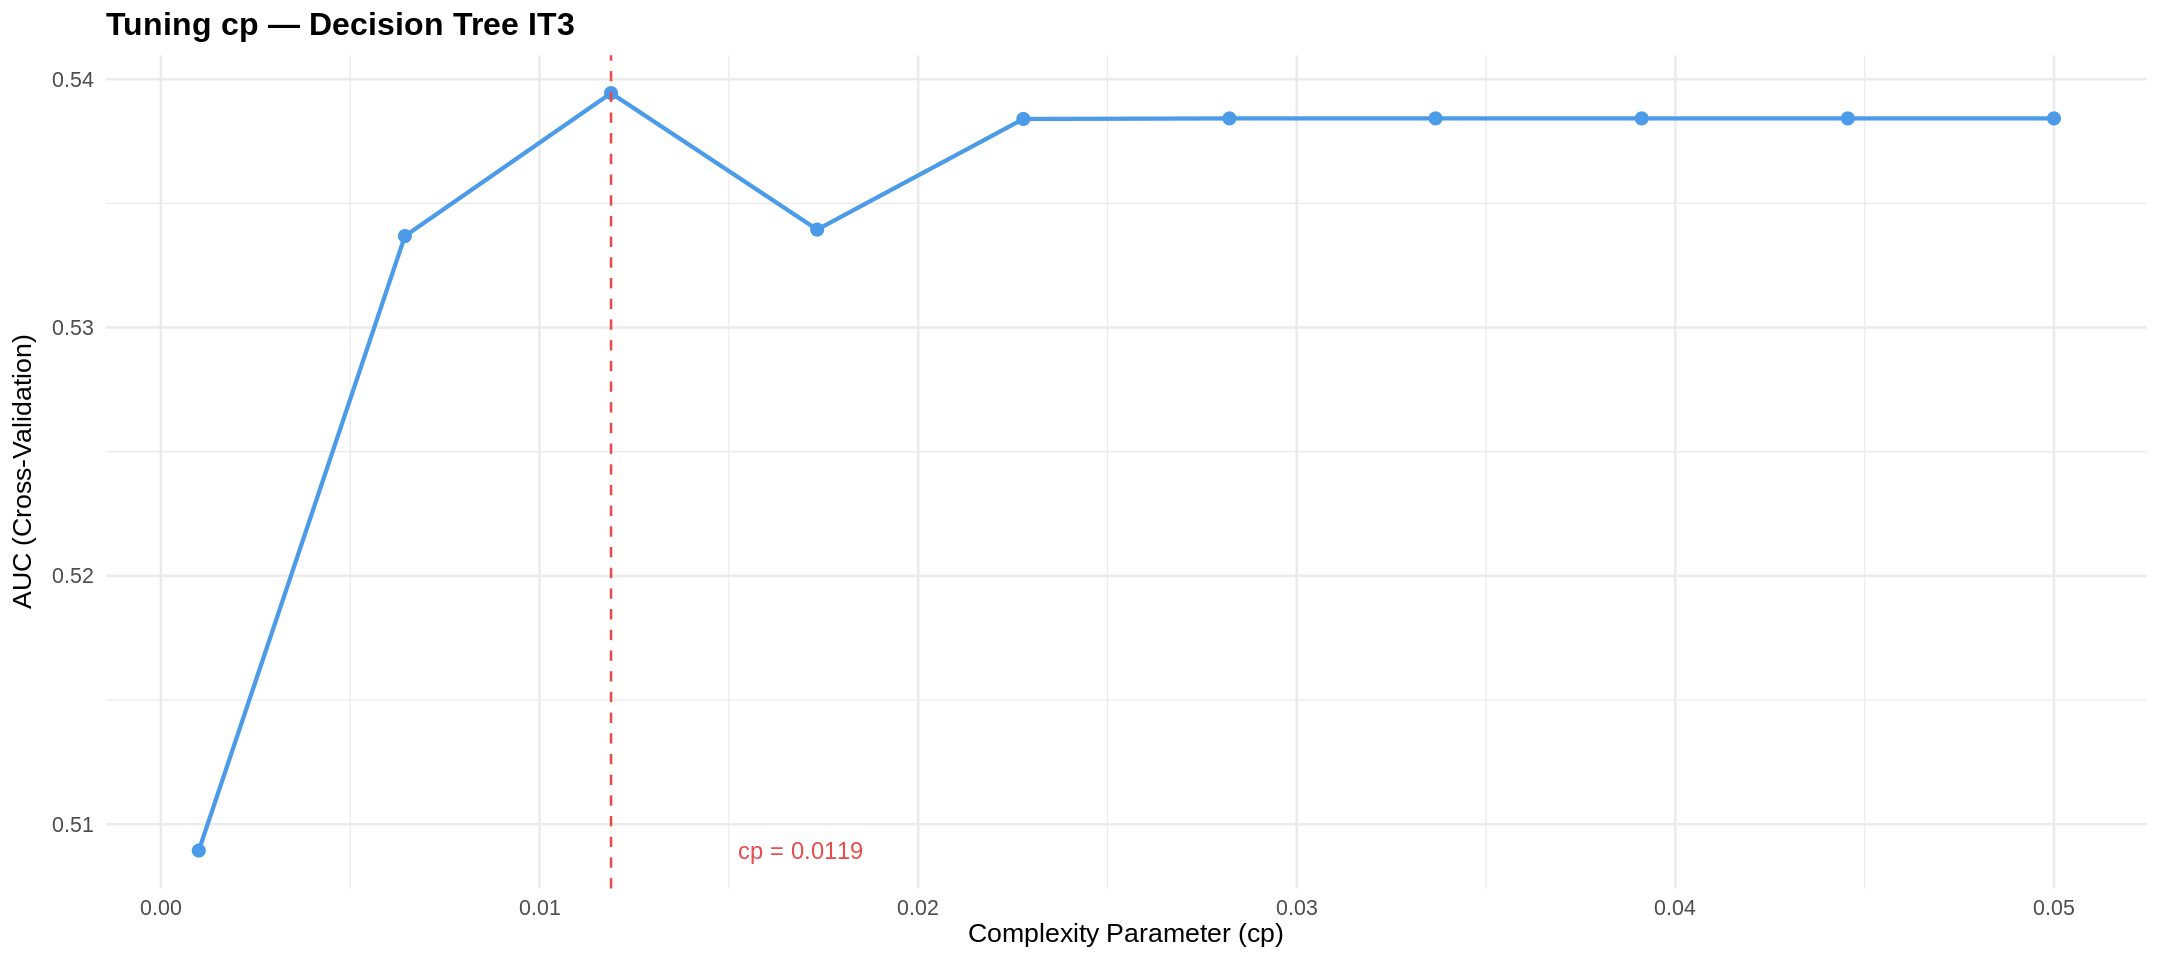

In [ ]:
ggplot(dt_model$results, aes(x = cp, y = ROC)) +
  geom_line(color = "#4C9BE8", linewidth = 1.2) +
  geom_point(color = "#4C9BE8", size = 3) +
  geom_vline(xintercept = dt_model$bestTune$cp,
             linetype = "dashed", color = "#E84C4C") +
  annotate("text",
           x = dt_model$bestTune$cp + 0.005,
           y = min(dt_model$results$ROC),
           label = paste0("cp = ", round(dt_model$bestTune$cp, 4)),
           color = "#E84C4C", size = 5) +
  labs(title = "Tuning cp — Decision Tree IT3",
       x = "Complexity Parameter (cp)", y = "AUC (Cross-Validation)") +
  theme_minimal(base_size = 16) +
  theme(plot.title = element_text(face = "bold"))

### 6.3 Visualização da Árvore

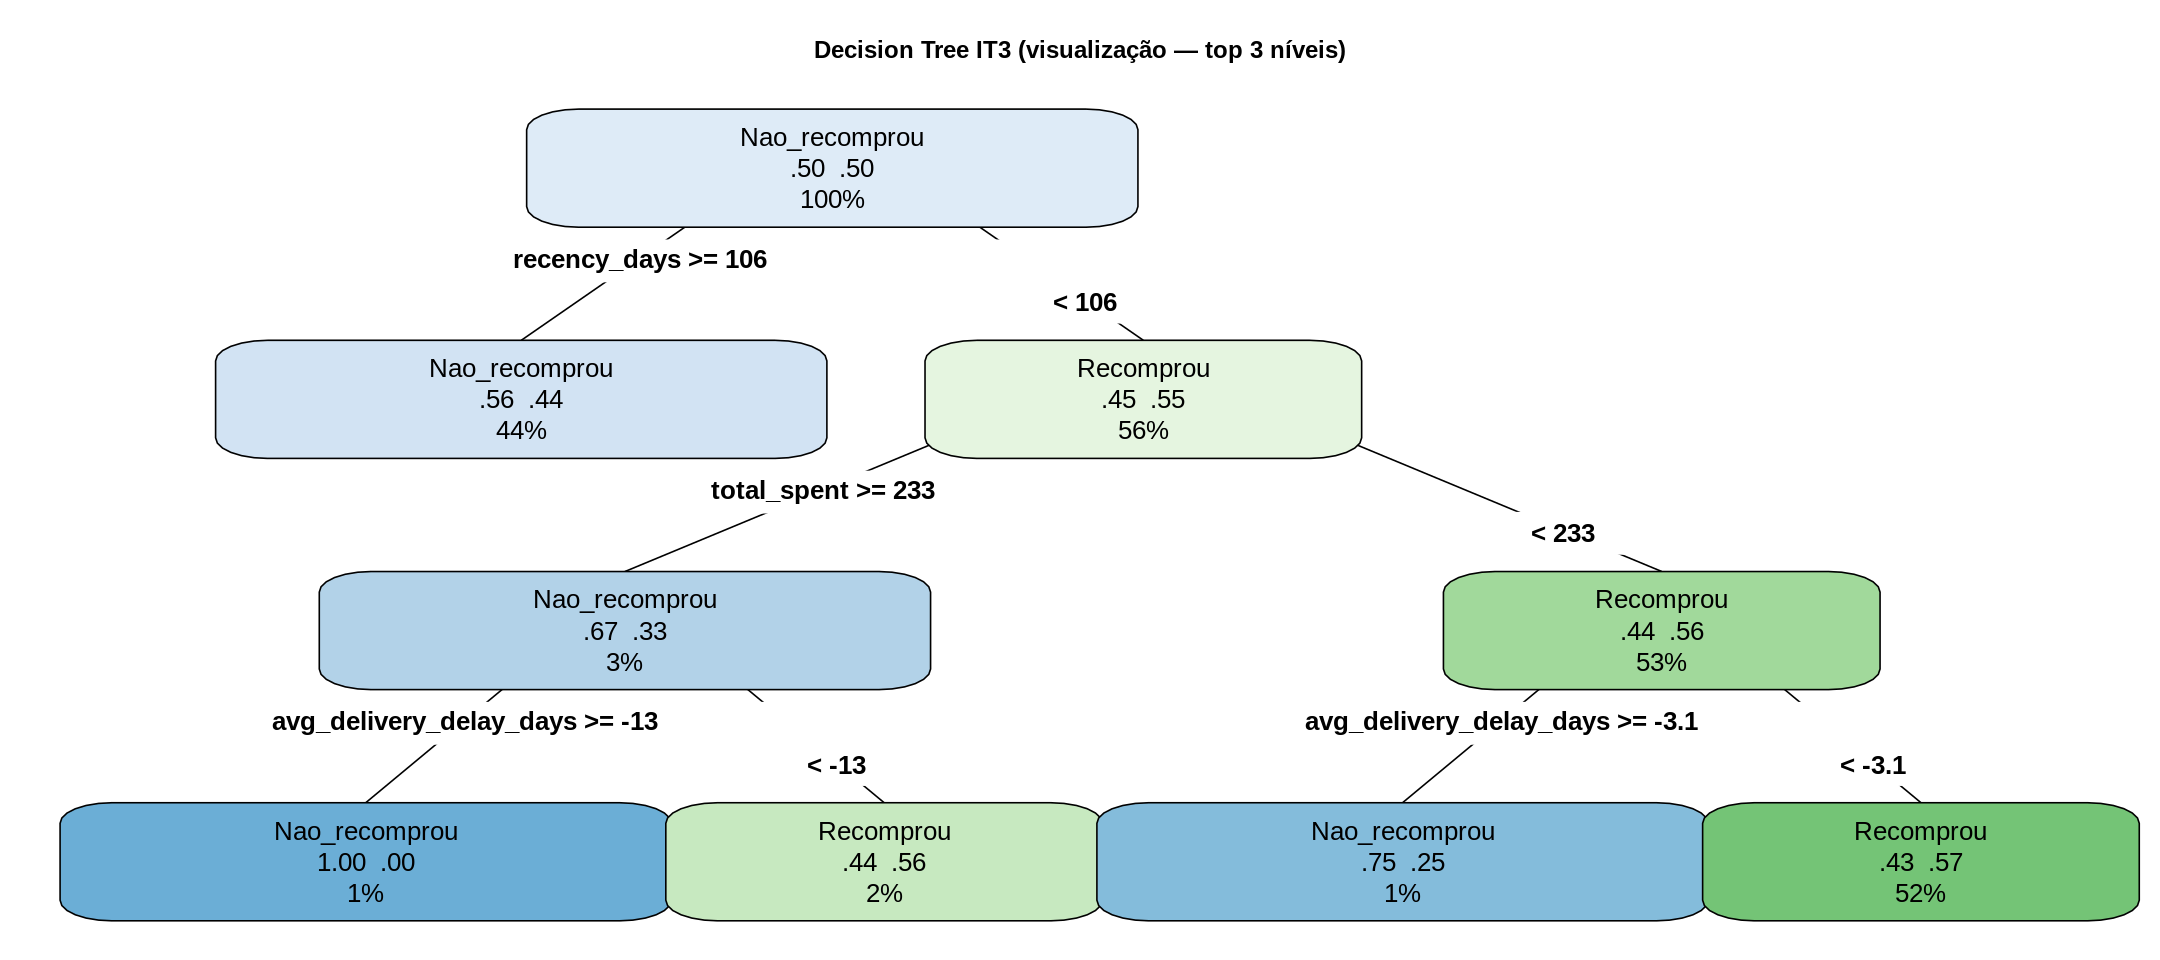

In [ ]:
set.seed(811)
dt_viz <- rpart(target_repurchase ~ .,
                data    = treino_final,
                method  = "class",
                control = rpart.control(maxdepth = 3, cp = 0.001),
                weights = pesos_treino)

rpart.plot(dt_viz,
           main          = "Decision Tree IT3 (visualização — top 3 níveis)",
           type          = 4,
           extra         = 104,
           fallen.leaves = FALSE,
           tweak         = 1.3)

### 6.4 Confusion Matrix

Confusion Matrix and Statistics

               Reference
Prediction      Nao_recomprou Recomprou
  Nao_recomprou          4998       116
  Recomprou              1933        49
                                          
               Accuracy : 0.7112          
                 95% CI : (0.7005, 0.7218)
    No Information Rate : 0.9767          
    P-Value [Acc > NIR] : 1               
                                          
                  Kappa : 0.0028          
                                          
 Mcnemar's Test P-Value : <2e-16          
                                          
            Sensitivity : 0.296970        
            Specificity : 0.721108        
         Pos Pred Value : 0.024723        
         Neg Pred Value : 0.977317        
             Prevalence : 0.023253        
         Detection Rate : 0.006905        
   Detection Prevalence : 0.279312        
      Balanced Accuracy : 0.509039        
                                          
     

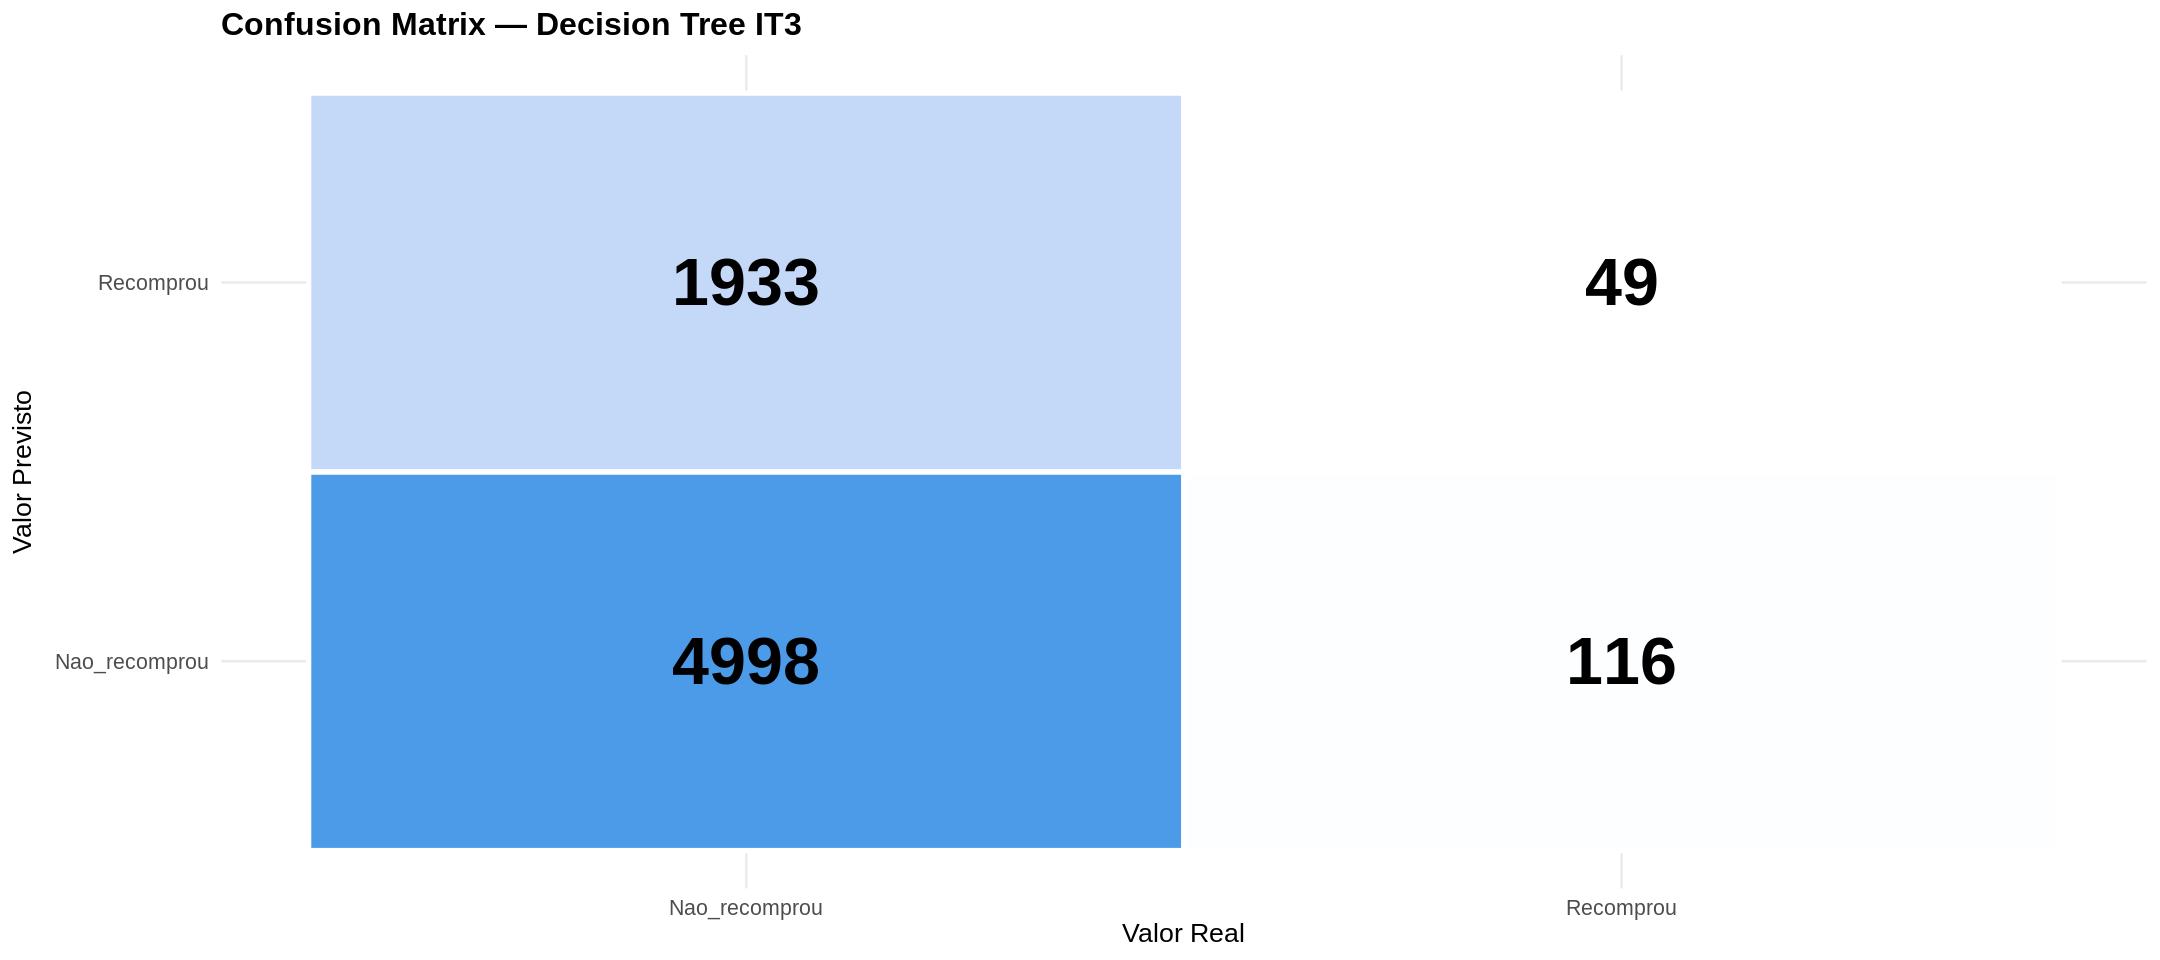

In [ ]:
pred_dt <- predict(dt_model, newdata = teste_final)

cm_dt <- confusionMatrix(pred_dt, teste_final$target_repurchase,
                         positive = "Recomprou")
print(cm_dt)

cm_table_dt <- as.data.frame(cm_dt$table)

ggplot(cm_table_dt, aes(x = Reference, y = Prediction, fill = Freq)) +
  geom_tile(colour = "white", linewidth = 1.5) +
  geom_text(aes(label = Freq), size = 14, fontface = "bold") +
  scale_fill_gradient(low = "white", high = "#4C9BE8") +
  labs(title = "Confusion Matrix — Decision Tree IT3",
       x = "Valor Real", y = "Valor Previsto") +
  theme_minimal(base_size = 16) +
  theme(legend.position = "none", plot.title = element_text(face = "bold"))

### 6.5 Métricas

In [ ]:
precision_dt <- cm_dt$byClass["Pos Pred Value"]
recall_dt    <- cm_dt$byClass["Sensitivity"]
f1_dt        <- 2 * (precision_dt * recall_dt) / (precision_dt + recall_dt)
accuracy_dt  <- cm_dt$overall["Accuracy"]

cat("Accuracy: ", round(accuracy_dt,  4), "\n")
cat("Precision:", round(precision_dt, 4), "\n")
cat("Recall:   ", round(recall_dt,    4), "\n")
cat("F1-Score: ", round(f1_dt,        4), "\n")

Accuracy:  0.7112 
Precision: 0.0247 
Recall:    0.297 
F1-Score:  0.0456 


### 6.6 ROC Curve

Setting direction: controls < cases



ROC-AUC — Decision Tree IT3: 0.4824 


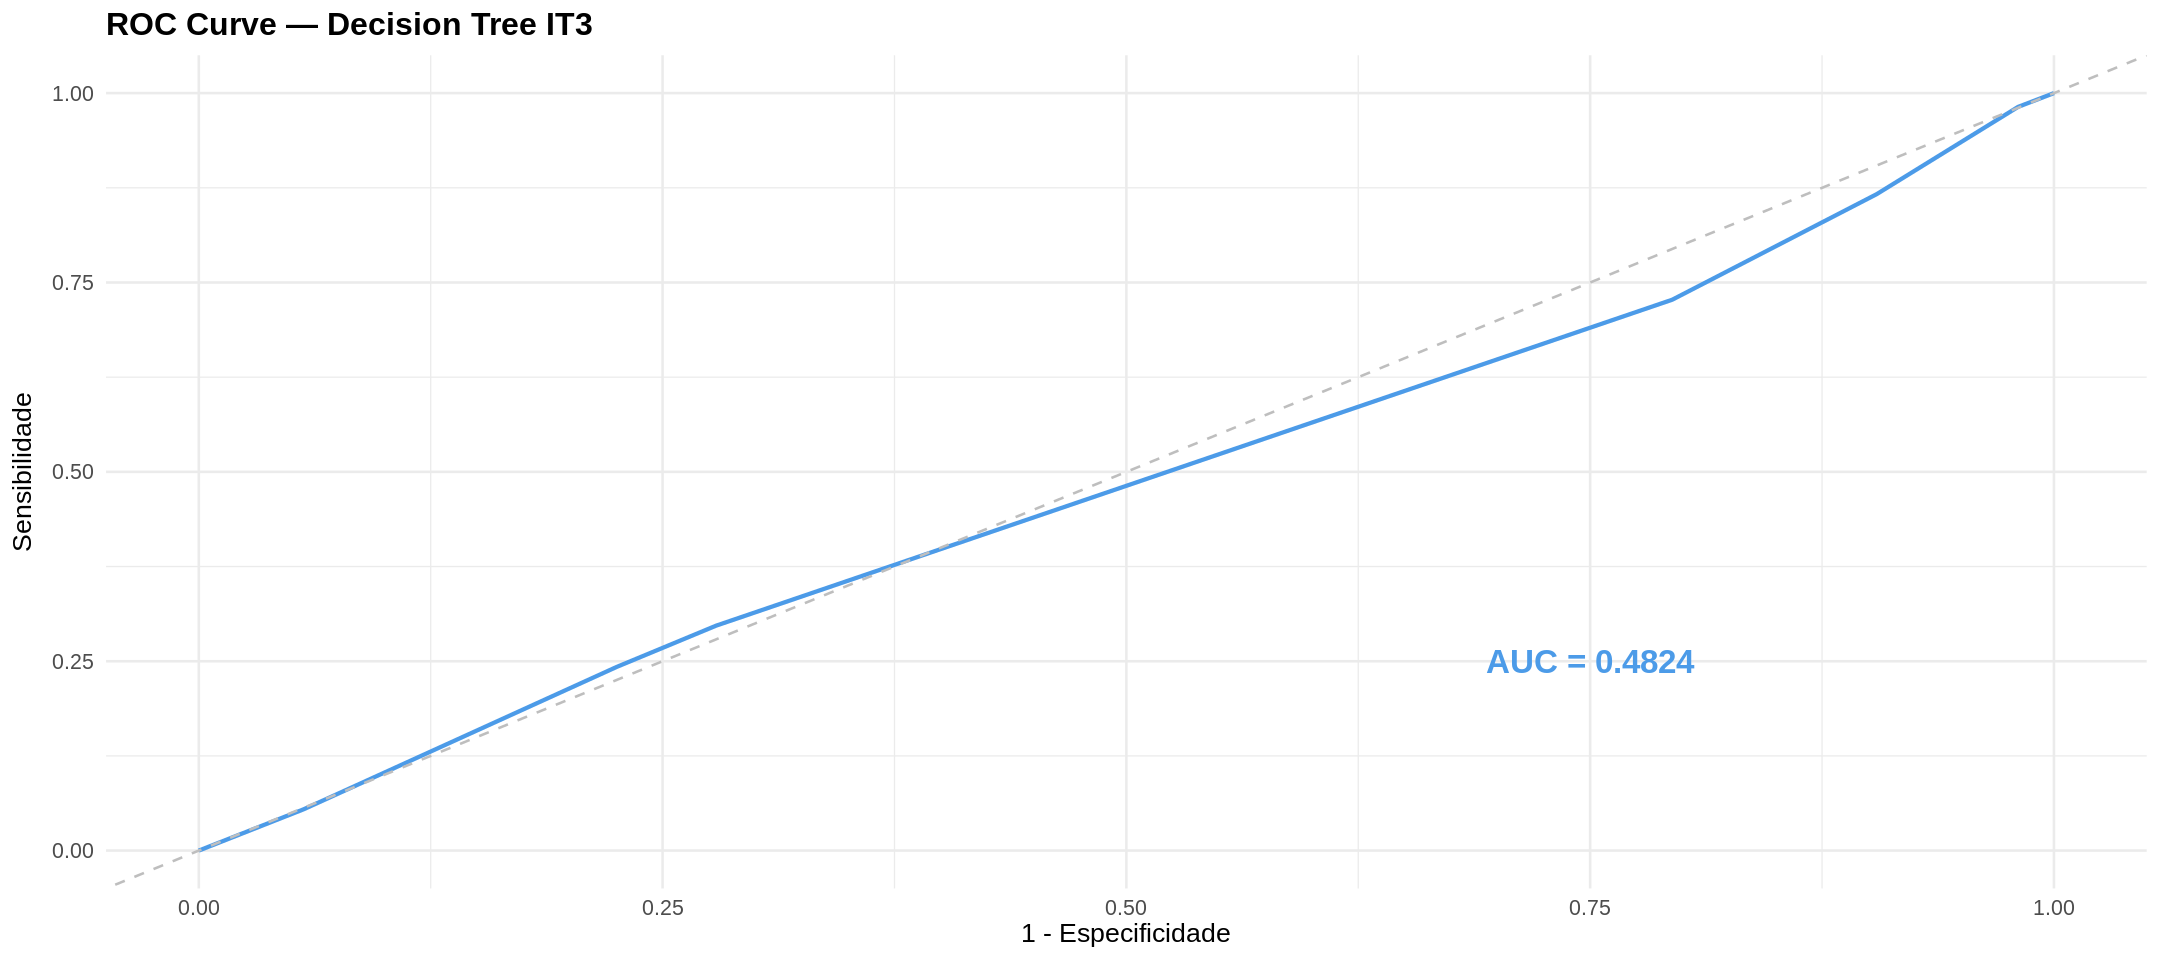

In [ ]:
prob_dt <- predict(dt_model, newdata = teste_final, type = "prob")[, "Recomprou"]

roc_dt <- roc(teste_final$target_repurchase, prob_dt,
              levels = c("Nao_recomprou", "Recomprou"))
auc_dt_roc <- round(auc(roc_dt), 4)
cat("ROC-AUC — Decision Tree IT3:", auc_dt_roc, "\n")

roc_df_dt <- data.frame(
  specificity = rev(roc_dt$specificities),
  sensitivity = rev(roc_dt$sensitivities)
)

ggplot(roc_df_dt, aes(x = 1 - specificity, y = sensitivity)) +
  geom_line(color = "#4C9BE8", linewidth = 1.2) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "gray") +
  annotate("text", x = 0.75, y = 0.25,
           label = paste0("AUC = ", auc_dt_roc),
           size = 7, color = "#4C9BE8", fontface = "bold") +
  labs(title = "ROC Curve — Decision Tree IT3",
       x = "1 - Especificidade", y = "Sensibilidade") +
  theme_minimal(base_size = 16) +
  theme(plot.title = element_text(face = "bold"))

### 6.7 PR Curve

PR-AUC  — Decision Tree IT3: 0.0229 
Baseline PR-AUC: 0.0233 


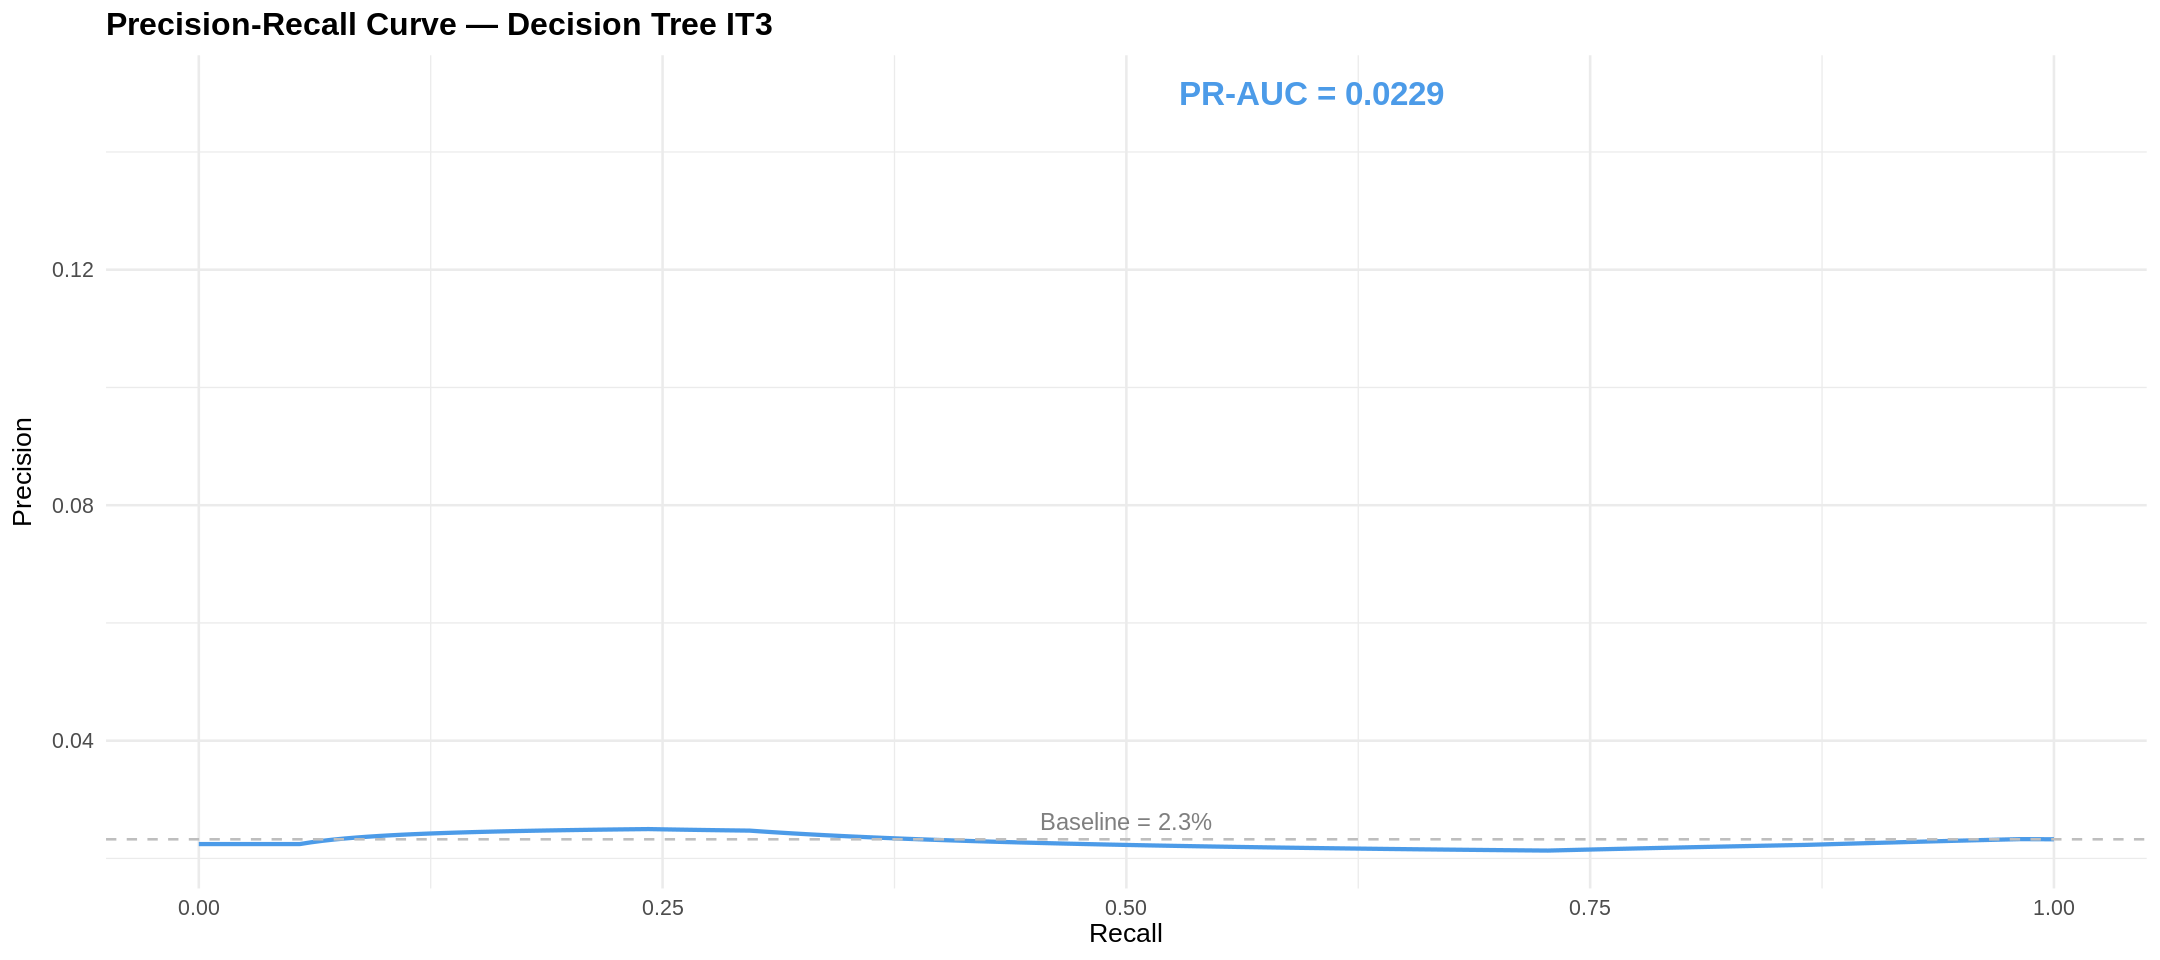

In [ ]:
pr_dt <- pr.curve(
  scores.class0 = prob_dt[teste_final$target_repurchase == "Recomprou"],
  scores.class1 = prob_dt[teste_final$target_repurchase == "Nao_recomprou"],
  curve         = TRUE
)
auc_dt_pr <- round(pr_dt$auc.integral, 4)
cat("PR-AUC  — Decision Tree IT3:", auc_dt_pr, "\n")
cat("Baseline PR-AUC:", round(baseline_pr, 4), "\n")

pr_df_dt <- data.frame(recall = pr_dt$curve[, 1], precision = pr_dt$curve[, 2])

ggplot(pr_df_dt, aes(x = recall, y = precision)) +
  geom_line(color = "#4C9BE8", linewidth = 1.2) +
  geom_hline(yintercept = baseline_pr, linetype = "dashed", color = "gray") +
  annotate("text", x = 0.5, y = baseline_pr + 0.003,
           label = paste0("Baseline = ", round(baseline_pr * 100, 1), "%"),
           color = "gray50", size = 5) +
  annotate("text", x = 0.6, y = 0.15,
           label = paste0("PR-AUC = ", auc_dt_pr),
           size = 7, color = "#4C9BE8", fontface = "bold") +
  labs(title = "Precision-Recall Curve — Decision Tree IT3",
       x = "Recall", y = "Precision") +
  theme_minimal(base_size = 16) +
  theme(plot.title = element_text(face = "bold"))

## 7. Random Forest

### 7.1 Treino

In [ ]:
set.seed(811)
rf_model <- train(
  target_repurchase ~ .,
  data       = treino_final,
  method     = "rf",
  trControl  = ctrl_cv,
  metric     = "ROC",
  tuneLength = 5,
  classwt    = c("Nao_recomprou" = 1, "Recomprou" = ratio)
)

cat("Melhor mtry:", rf_model$bestTune$mtry, "\n")

Melhor mtry: 2 


### 7.2 Tuning do mtry

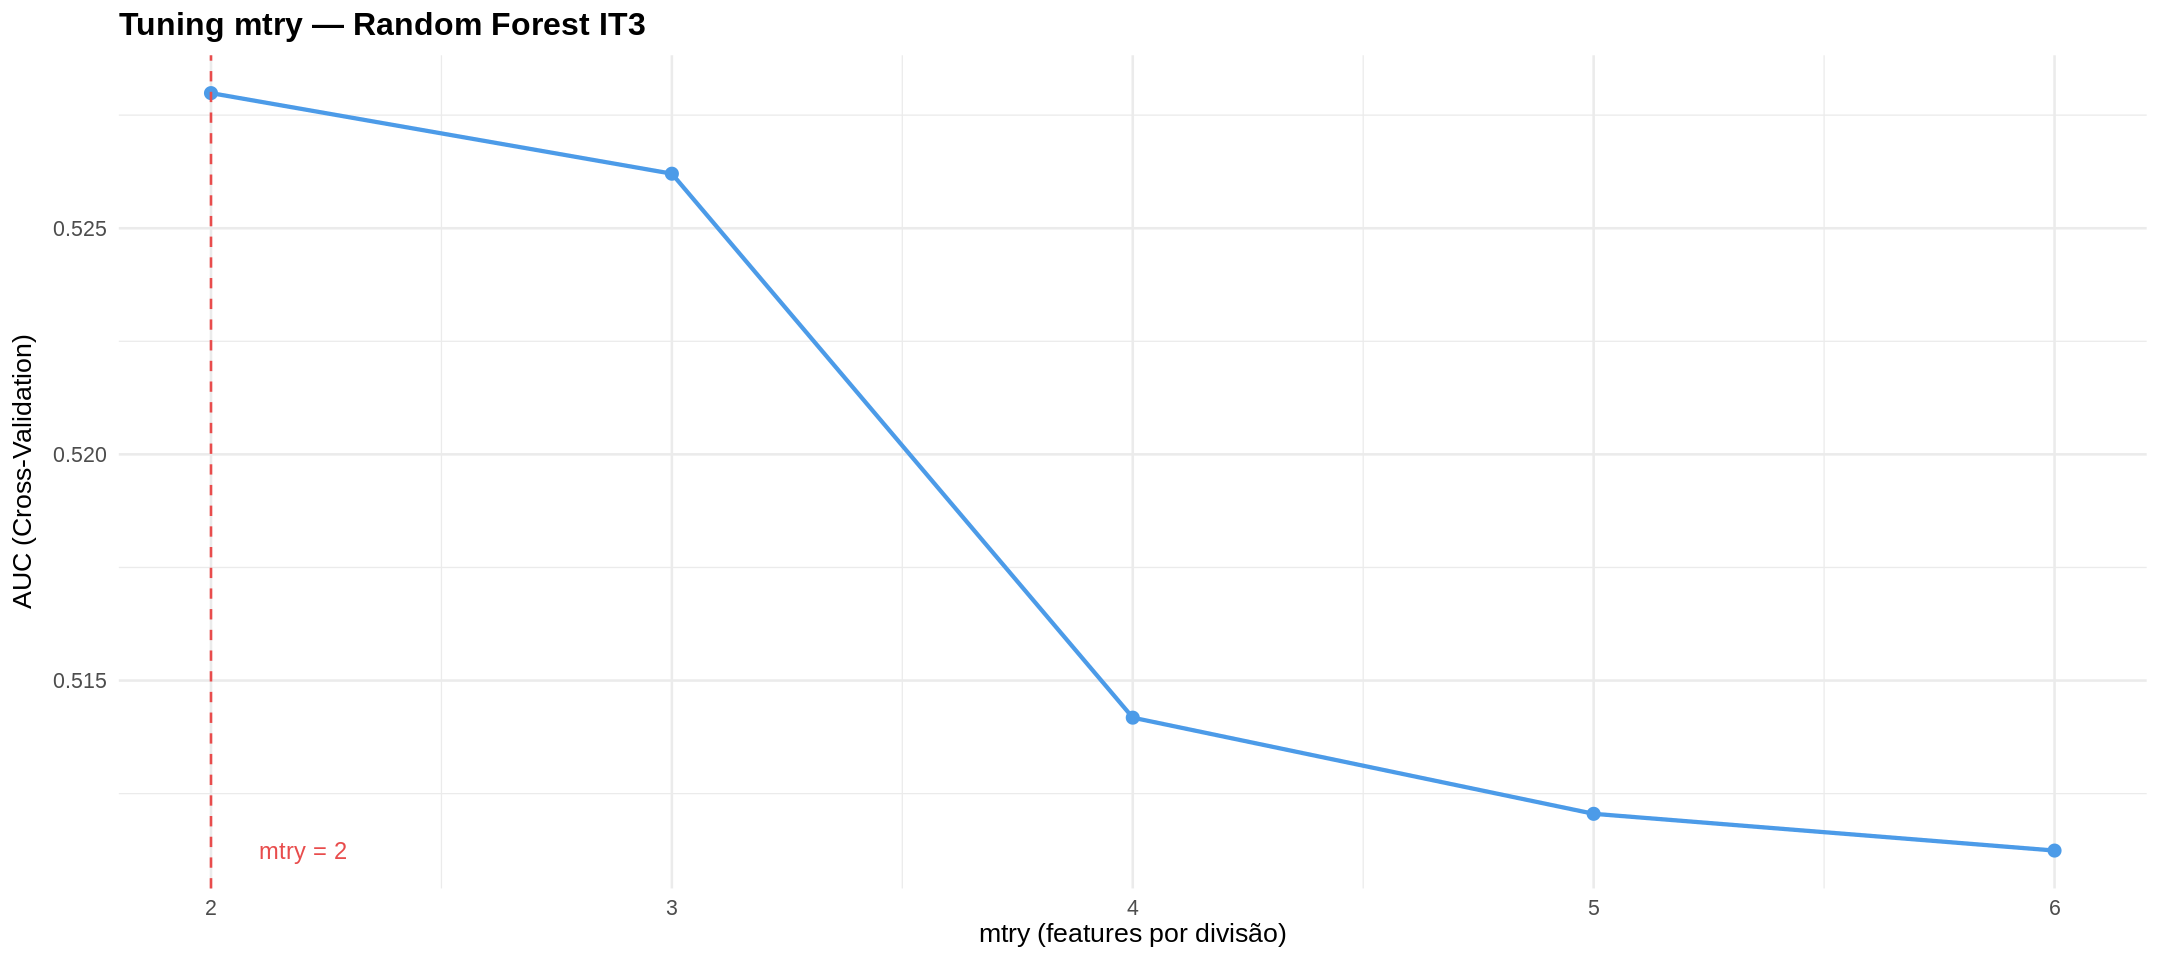

In [ ]:
ggplot(rf_model$results, aes(x = mtry, y = ROC)) +
  geom_line(color = "#4C9BE8", linewidth = 1.2) +
  geom_point(color = "#4C9BE8", size = 3) +
  geom_vline(xintercept = rf_model$bestTune$mtry,
             linetype = "dashed", color = "#E84C4C") +
  annotate("text",
           x = rf_model$bestTune$mtry + 0.2,
           y = min(rf_model$results$ROC),
           label = paste0("mtry = ", rf_model$bestTune$mtry),
           color = "#E84C4C", size = 5) +
  labs(title = "Tuning mtry — Random Forest IT3",
       x = "mtry (features por divisão)", y = "AUC (Cross-Validation)") +
  theme_minimal(base_size = 16) +
  theme(plot.title = element_text(face = "bold"))

### 7.3 Confusion Matrix

Confusion Matrix and Statistics

               Reference
Prediction      Nao_recomprou Recomprou
  Nao_recomprou          4115       100
  Recomprou              2816        65
                                          
               Accuracy : 0.5891          
                 95% CI : (0.5775, 0.6005)
    No Information Rate : 0.9767          
    P-Value [Acc > NIR] : 1               
                                          
                  Kappa : -0.0014         
                                          
 Mcnemar's Test P-Value : <2e-16          
                                          
            Sensitivity : 0.39394         
            Specificity : 0.59371         
         Pos Pred Value : 0.02256         
         Neg Pred Value : 0.97628         
             Prevalence : 0.02325         
         Detection Rate : 0.00916         
   Detection Prevalence : 0.40600         
      Balanced Accuracy : 0.49382         
                                          
     

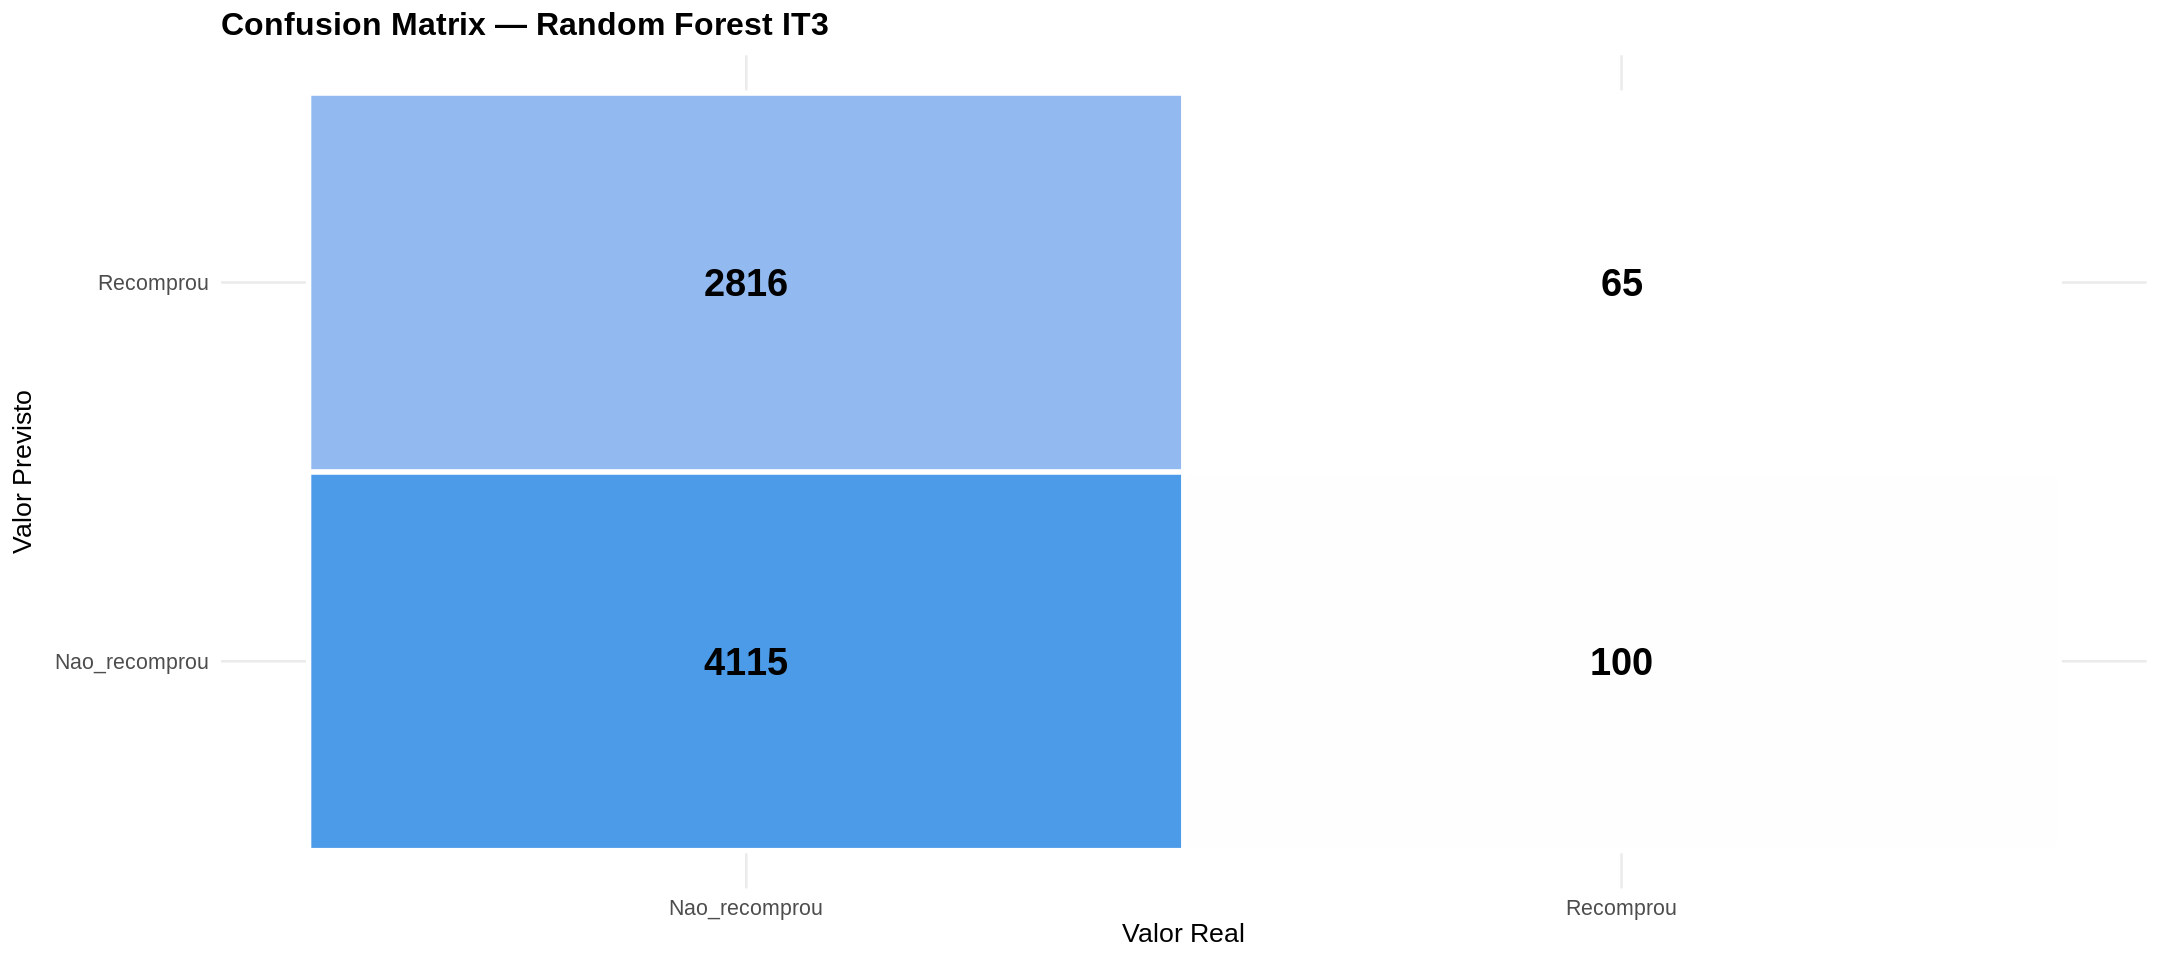

In [ ]:
pred_rf <- predict(rf_model, newdata = teste_final)

cm_rf <- confusionMatrix(pred_rf, teste_final$target_repurchase,
                         positive = "Recomprou")
print(cm_rf)

cm_table_rf <- as.data.frame(cm_rf$table)

ggplot(cm_table_rf, aes(x = Reference, y = Prediction, fill = Freq)) +
  geom_tile(colour = "white", linewidth = 1.5) +
  geom_text(aes(label = Freq), size = 8, fontface = "bold") +
  scale_fill_gradient(low = "white", high = "#4C9BE8") +
  labs(title = "Confusion Matrix — Random Forest IT3",
       x = "Valor Real", y = "Valor Previsto") +
  theme_minimal(base_size = 16) +
  theme(legend.position = "none", plot.title = element_text(face = "bold"))

### 7.4 Métricas

In [ ]:
precision_rf <- cm_rf$byClass["Pos Pred Value"]
recall_rf    <- cm_rf$byClass["Sensitivity"]
f1_rf        <- 2 * (precision_rf * recall_rf) / (precision_rf + recall_rf)
accuracy_rf  <- cm_rf$overall["Accuracy"]

cat("Accuracy: ", round(accuracy_rf,  4), "\n")
cat("Precision:", round(precision_rf, 4), "\n")
cat("Recall:   ", round(recall_rf,    4), "\n")
cat("F1-Score: ", round(f1_rf,        4), "\n")

Accuracy:  0.5891 
Precision: 0.0226 
Recall:    0.3939 
F1-Score:  0.0427 


### 7.5 ROC Curve

Setting direction: controls > cases



ROC-AUC — Random Forest IT3: 0.5198 


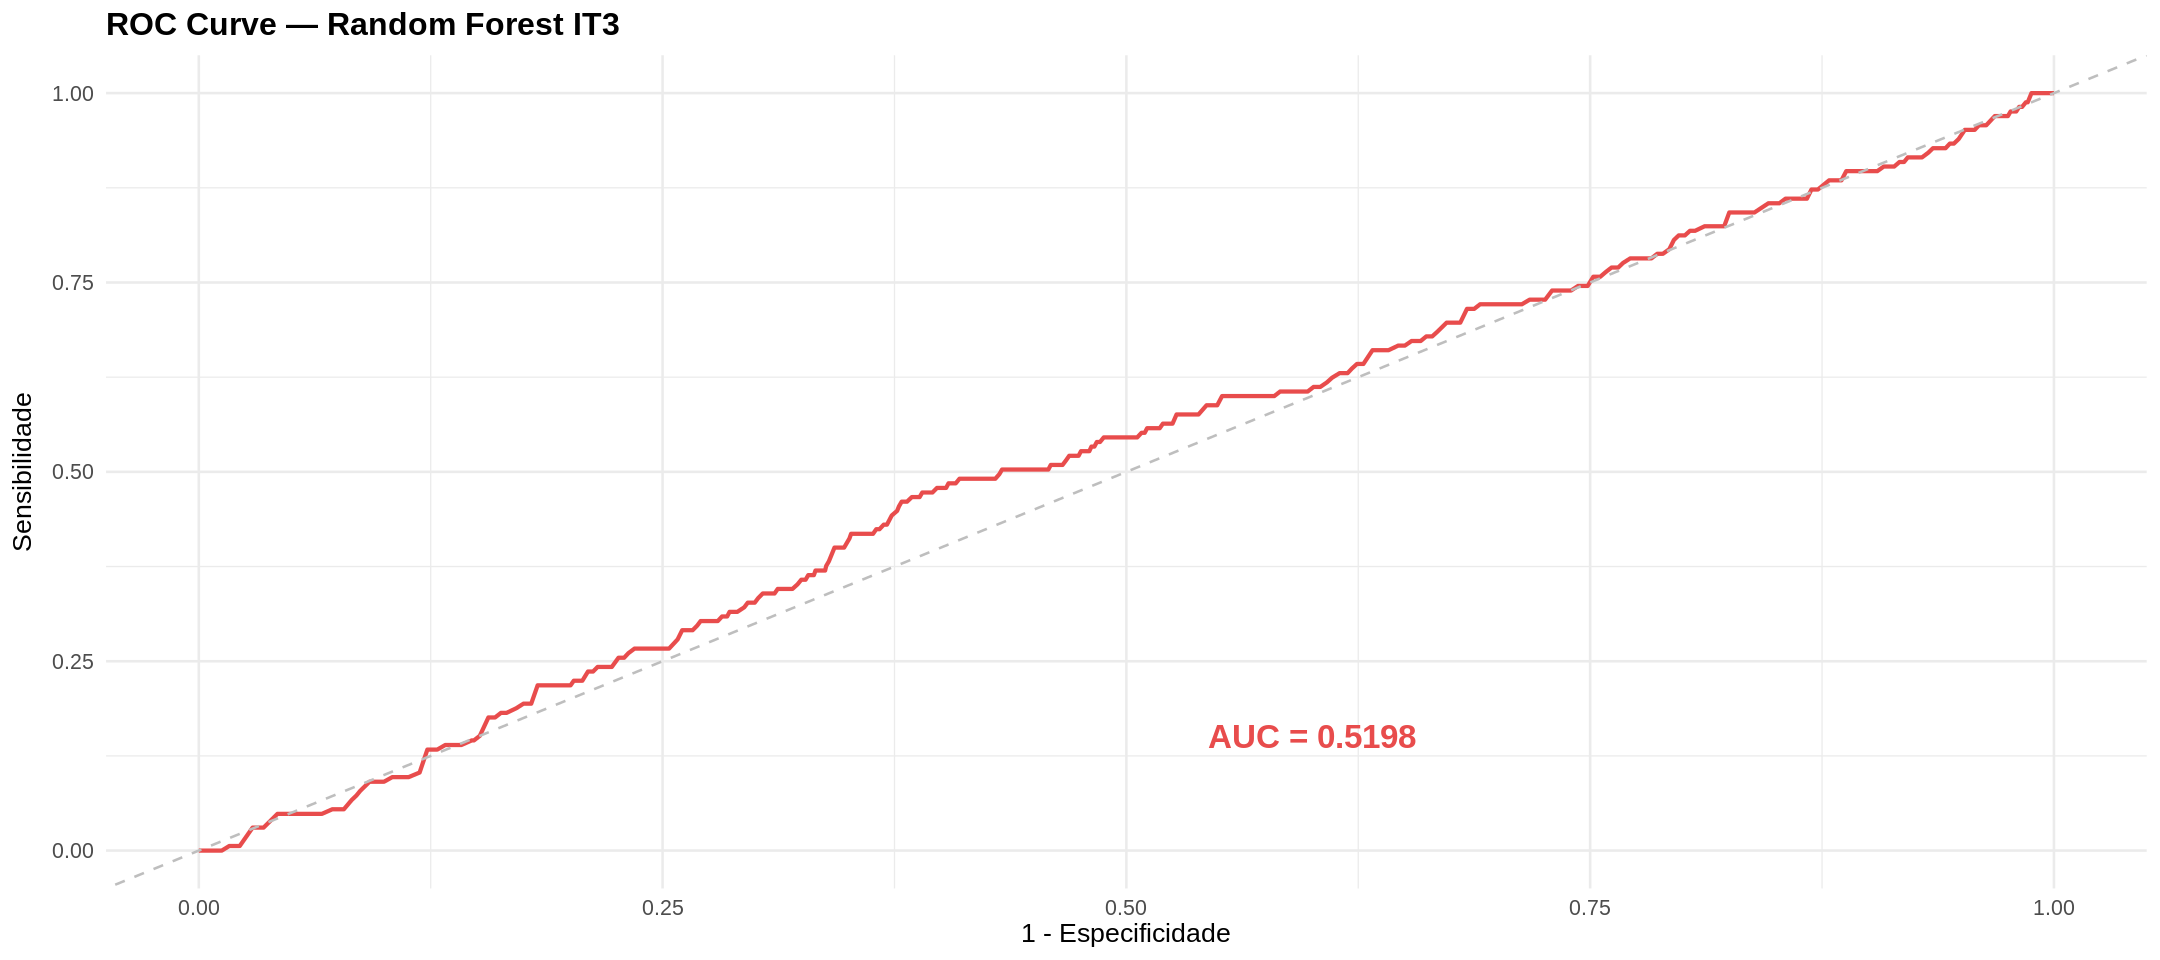

In [ ]:
prob_rf <- predict(rf_model, newdata = teste_final, type = "prob")[, "Recomprou"]

roc_rf <- roc(teste_final$target_repurchase, prob_rf,
              levels = c("Nao_recomprou", "Recomprou"))
auc_rf_roc <- round(auc(roc_rf), 4)
cat("ROC-AUC — Random Forest IT3:", auc_rf_roc, "\n")

roc_df_rf <- data.frame(
  specificity = rev(roc_rf$specificities),
  sensitivity = rev(roc_rf$sensitivities)
)

ggplot(roc_df_rf, aes(x = 1 - specificity, y = sensitivity)) +
  geom_line(color = "#E84C4C", linewidth = 1.2) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "gray") +
  annotate("text", x = 0.60, y = 0.15,
           label = paste0("AUC = ", auc_rf_roc),
           size = 7, color = "#E84C4C", fontface = "bold") +
  labs(title = "ROC Curve — Random Forest IT3",
       x = "1 - Especificidade", y = "Sensibilidade") +
  theme_minimal(base_size = 16) +
  theme(plot.title = element_text(face = "bold"))

### 7.6 PR Curve

PR-AUC  — Random Forest IT3: 0.0224 


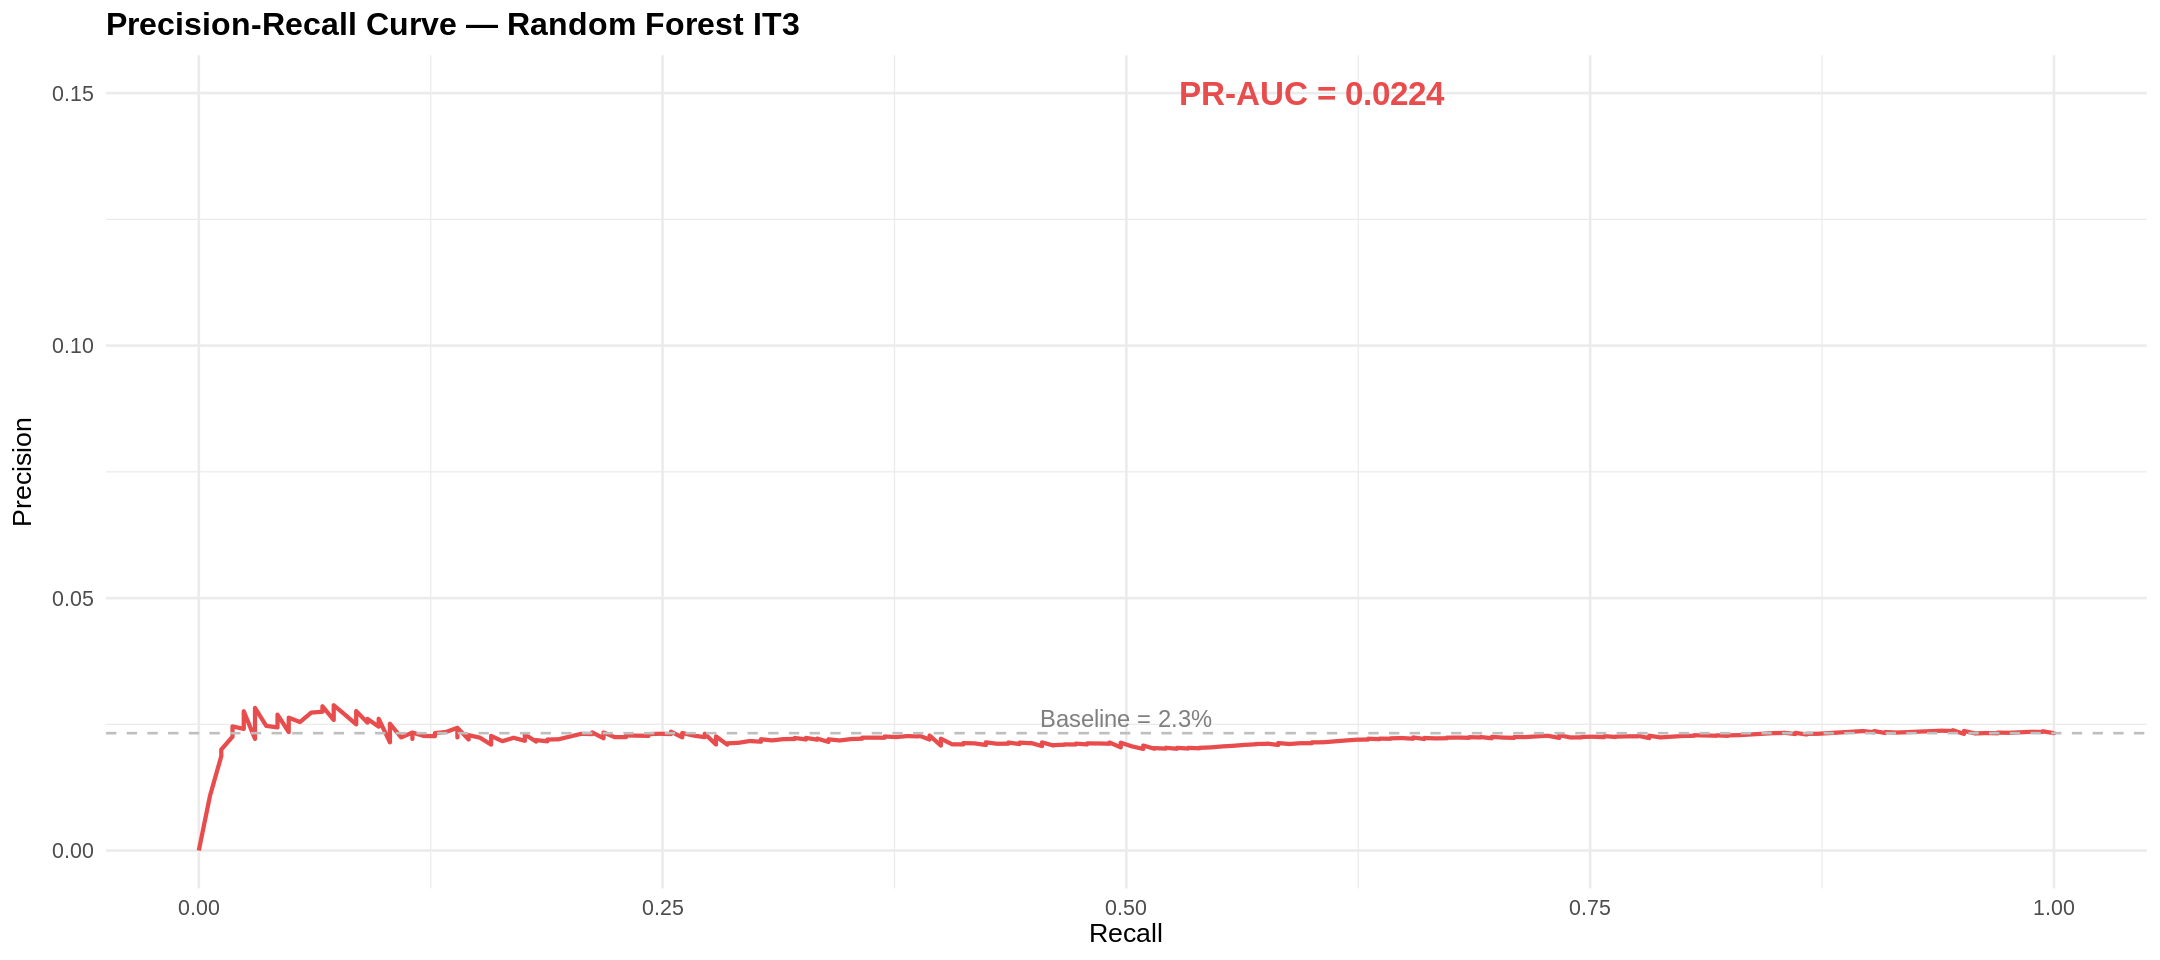

In [ ]:
pr_rf <- pr.curve(
  scores.class0 = prob_rf[teste_final$target_repurchase == "Recomprou"],
  scores.class1 = prob_rf[teste_final$target_repurchase == "Nao_recomprou"],
  curve         = TRUE
)
auc_rf_pr <- round(pr_rf$auc.integral, 4)
cat("PR-AUC  — Random Forest IT3:", auc_rf_pr, "\n")

pr_df_rf <- data.frame(recall = pr_rf$curve[, 1], precision = pr_rf$curve[, 2])

ggplot(pr_df_rf, aes(x = recall, y = precision)) +
  geom_line(color = "#E84C4C", linewidth = 1.2) +
  geom_hline(yintercept = baseline_pr, linetype = "dashed", color = "gray") +
  annotate("text", x = 0.5, y = baseline_pr + 0.003,
           label = paste0("Baseline = ", round(baseline_pr * 100, 1), "%"),
           color = "gray50", size = 5) +
  annotate("text", x = 0.6, y = 0.15,
           label = paste0("PR-AUC = ", auc_rf_pr),
           size = 7, color = "#E84C4C", fontface = "bold") +
  labs(title = "Precision-Recall Curve — Random Forest IT3",
       x = "Recall", y = "Precision") +
  theme_minimal(base_size = 16) +
  theme(plot.title = element_text(face = "bold"))

### 7.7 Feature Importance

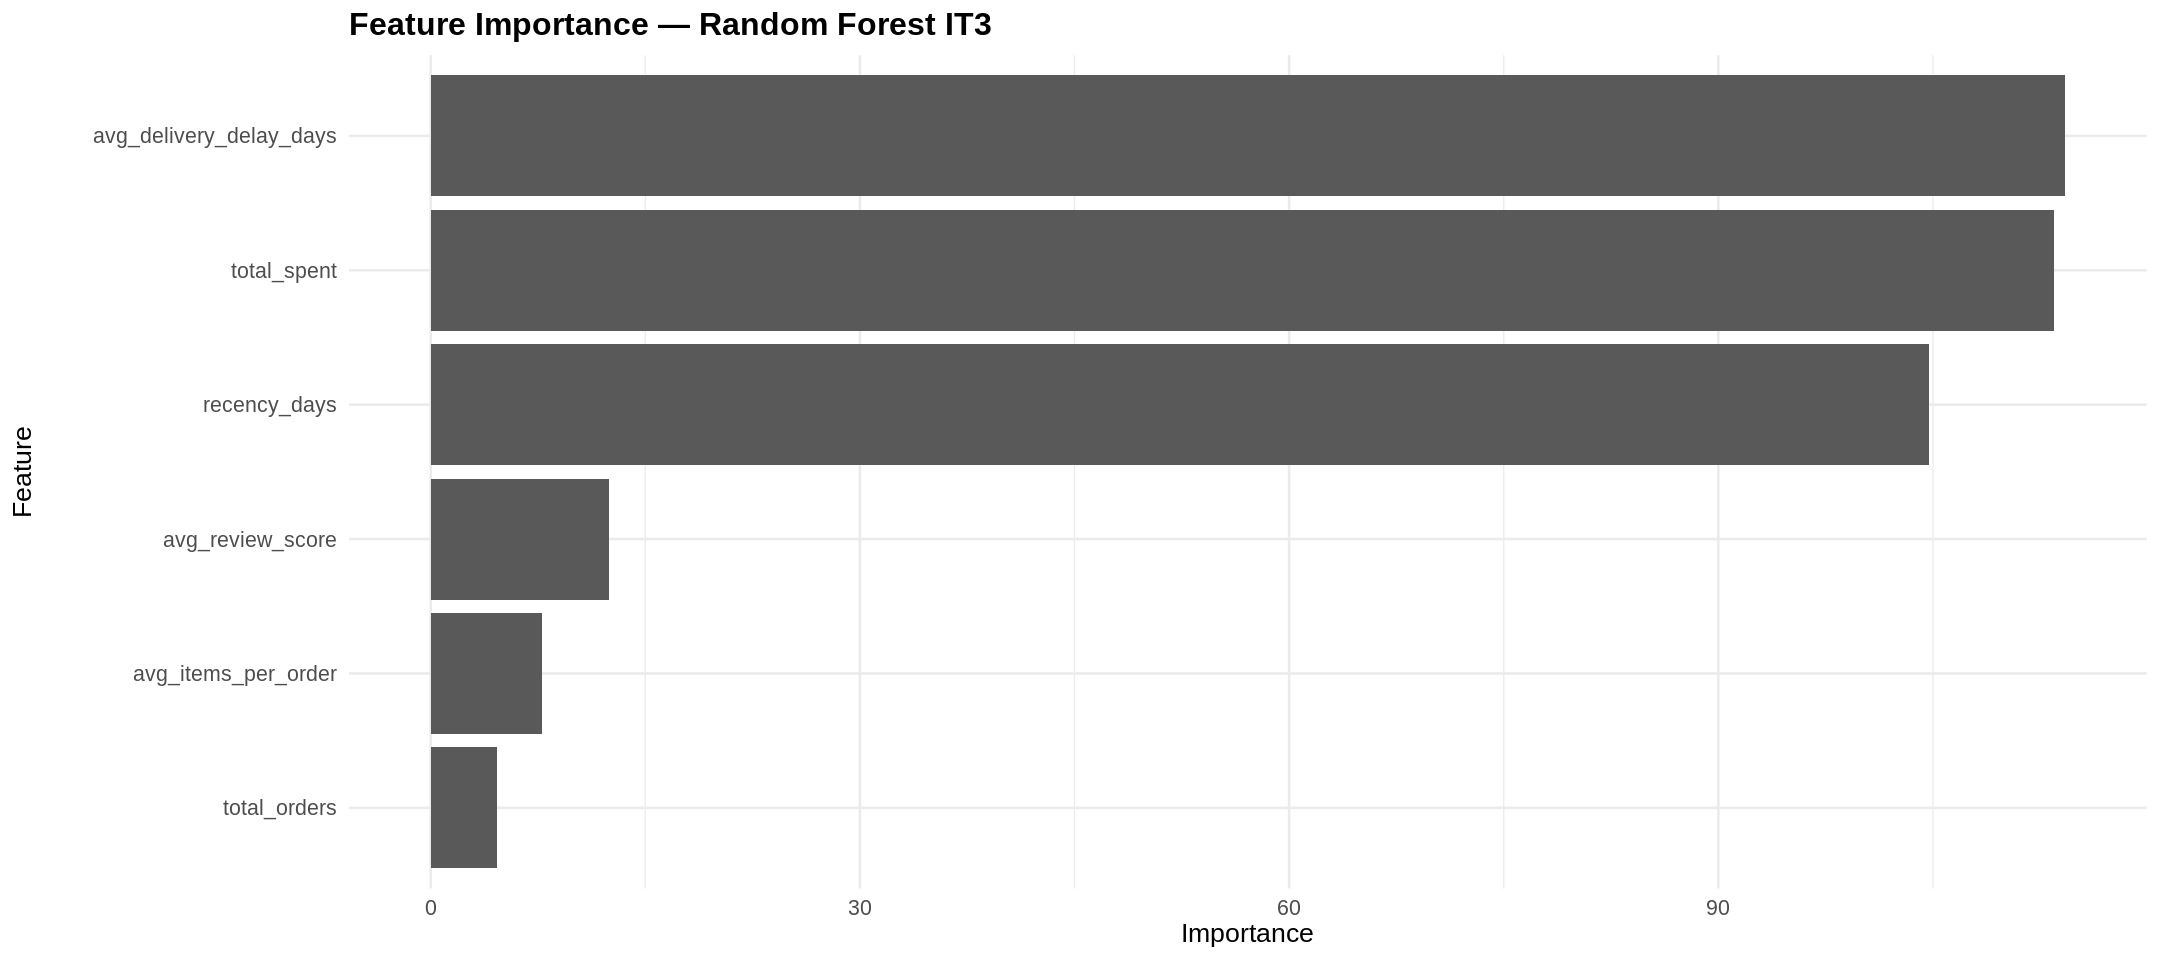

In [ ]:
importance_rf <- varImp(rf_model, scale = FALSE)

ggplot(importance_rf, top = 6) +
  labs(title = "Feature Importance — Random Forest IT3") +
  theme_minimal(base_size = 16) +
  theme(plot.title = element_text(face = "bold"))

## 8. Comparação dos Modelos

### 8.1 AUC por Fold (Cross-Validation)

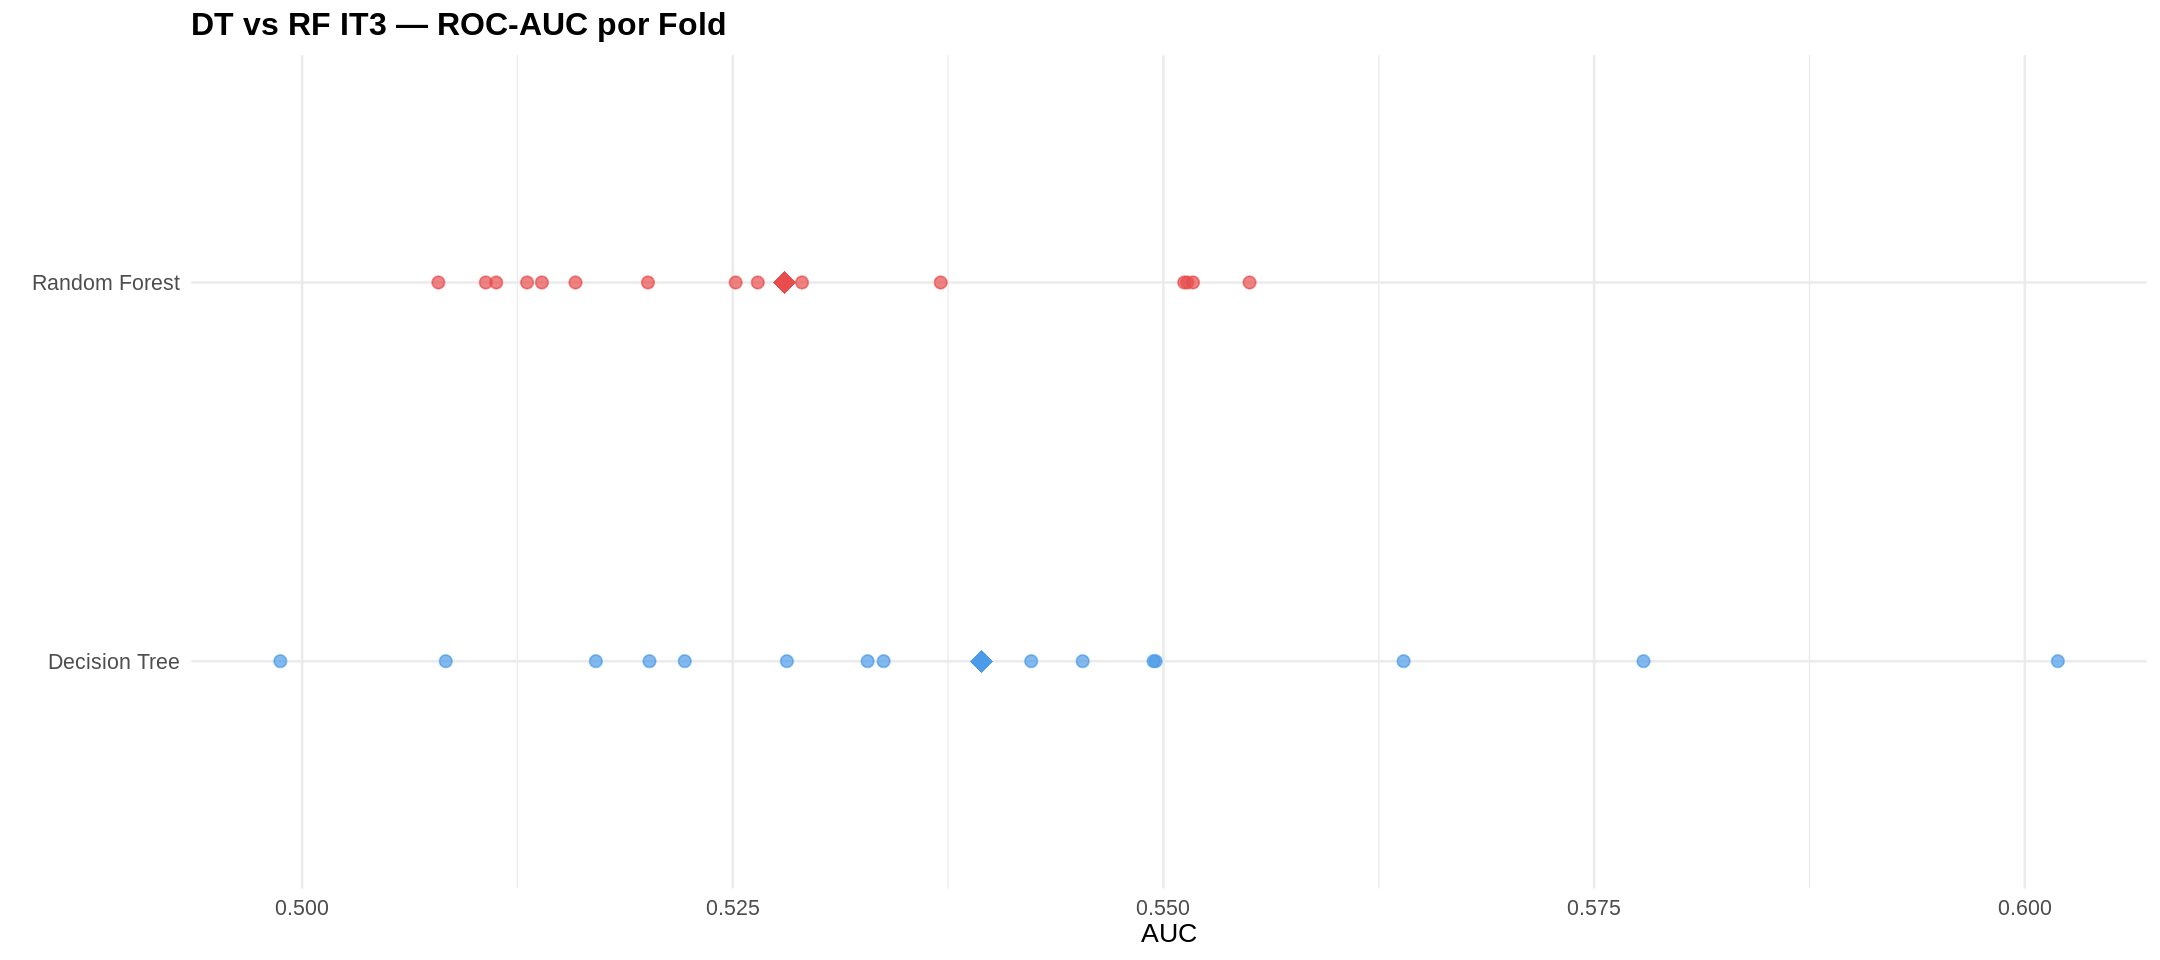

In [ ]:
resultados_cv <- resamples(list(
  "Decision Tree" = dt_model,
  "Random Forest" = rf_model
))

df_resamples <- as.data.frame(resultados_cv$values) %>%
  select(-Resample) %>%
  pivot_longer(everything(), names_to = "modelo_metrica", values_to = "valor") %>%
  filter(grepl("ROC", modelo_metrica)) %>%
  mutate(modelo = ifelse(grepl("Decision Tree", modelo_metrica),
                         "Decision Tree", "Random Forest"))

ggplot(df_resamples, aes(x = valor, y = modelo, color = modelo)) +
  geom_point(size = 3, alpha = 0.7) +
  stat_summary(fun = mean, geom = "point", size = 6, shape = 18) +
  scale_color_manual(values = c("Decision Tree" = "#4C9BE8",
                                "Random Forest" = "#E84C4C")) +
  labs(title = "DT vs RF IT3 — ROC-AUC por Fold", x = "AUC", y = NULL) +
  theme_minimal(base_size = 16) +
  theme(plot.title = element_text(face = "bold"), legend.position = "none")

### 8.2 Tabela Comparativa IT3

In [ ]:
tabela_it3 <- data.frame(
  Modelo    = c("Baseline", "Decision Tree IT3", "Random Forest IT3"),
  Accuracy  = c(round(mean(teste_final$target_repurchase == "Nao_recomprou"), 4),
                round(accuracy_dt, 4), round(accuracy_rf, 4)),
  Precision = c(NA, round(precision_dt, 4), round(precision_rf, 4)),
  Recall    = c(0,  round(recall_dt, 4),    round(recall_rf, 4)),
  F1_Score  = c(0,  round(f1_dt, 4),        round(f1_rf, 4)),
  ROC_AUC   = c(NA, auc_dt_roc, auc_rf_roc),
  PR_AUC    = c(round(baseline_pr, 4), auc_dt_pr, auc_rf_pr)
)

kable(tabela_it3, caption = "Comparação de Modelos IT3", digits = 4)



Table: Comparação de Modelos IT3

|Modelo            | Accuracy| Precision| Recall| F1_Score| ROC_AUC| PR_AUC|
|:-----------------|--------:|---------:|------:|--------:|-------:|------:|
|Baseline          |   0.9767|        NA| 0.0000|   0.0000|      NA| 0.0233|
|Decision Tree IT3 |   0.7112|    0.0247| 0.2970|   0.0456|  0.4824| 0.0229|
|Random Forest IT3 |   0.5891|    0.0226| 0.3939|   0.0427|  0.5198| 0.0224|

### 8.3 ROC Curves Sobrepostas

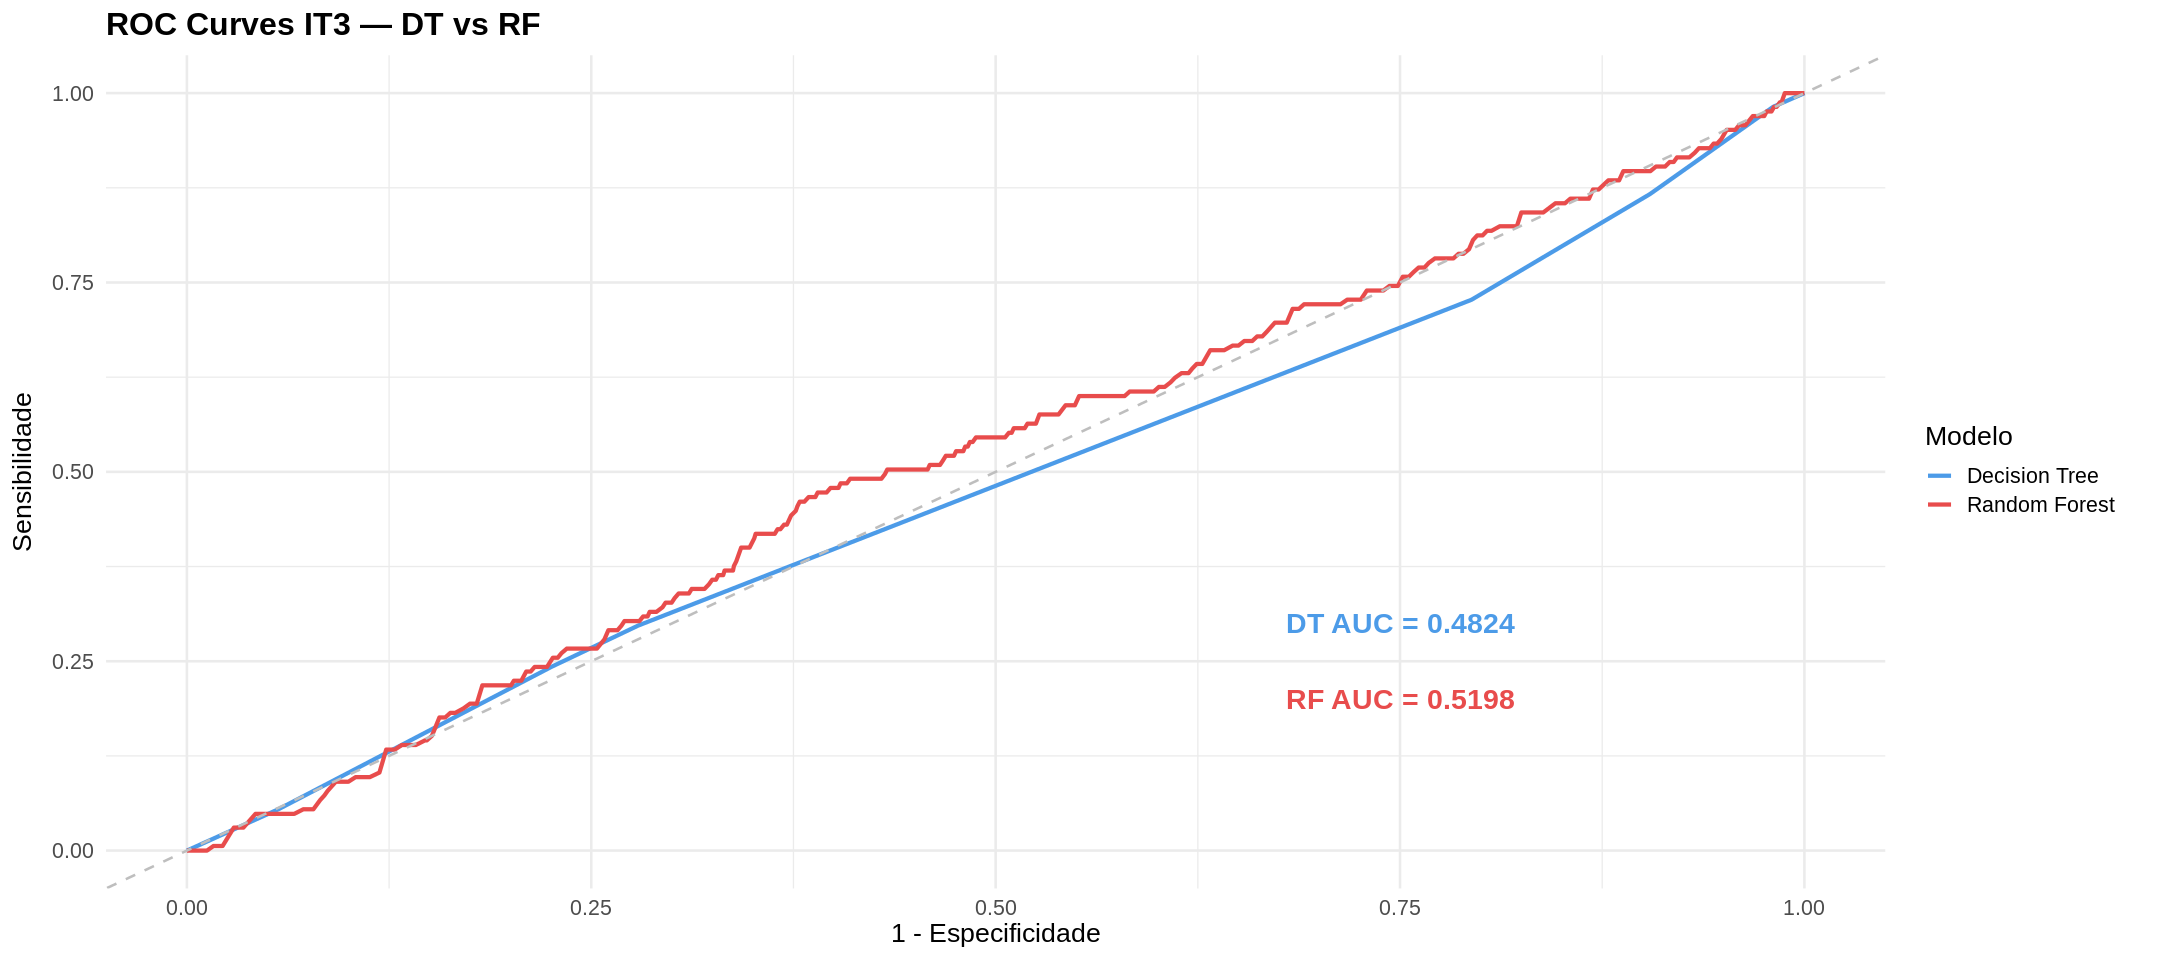

In [ ]:
roc_df_dt$modelo <- "Decision Tree"
roc_df_rf$modelo <- "Random Forest"
roc_combined     <- rbind(roc_df_dt, roc_df_rf)

ggplot(roc_combined, aes(x = 1 - specificity, y = sensitivity, color = modelo)) +
  geom_line(linewidth = 1.2) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "gray") +
  scale_color_manual(values = c("Decision Tree" = "#4C9BE8",
                                "Random Forest" = "#E84C4C")) +
  annotate("text", x = 0.75, y = 0.30,
           label = paste0("DT AUC = ", auc_dt_roc),
           color = "#4C9BE8", size = 6, fontface = "bold") +
  annotate("text", x = 0.75, y = 0.20,
           label = paste0("RF AUC = ", auc_rf_roc),
           color = "#E84C4C", size = 6, fontface = "bold") +
  labs(title = "ROC Curves IT3 — DT vs RF",
       x = "1 - Especificidade", y = "Sensibilidade", color = "Modelo") +
  theme_minimal(base_size = 16) +
  theme(plot.title = element_text(face = "bold"))

### 8.4 Análise do Threshold

Warning message:
“Removed 5 rows containing missing values or values outside the scale range
(`geom_line()`).”


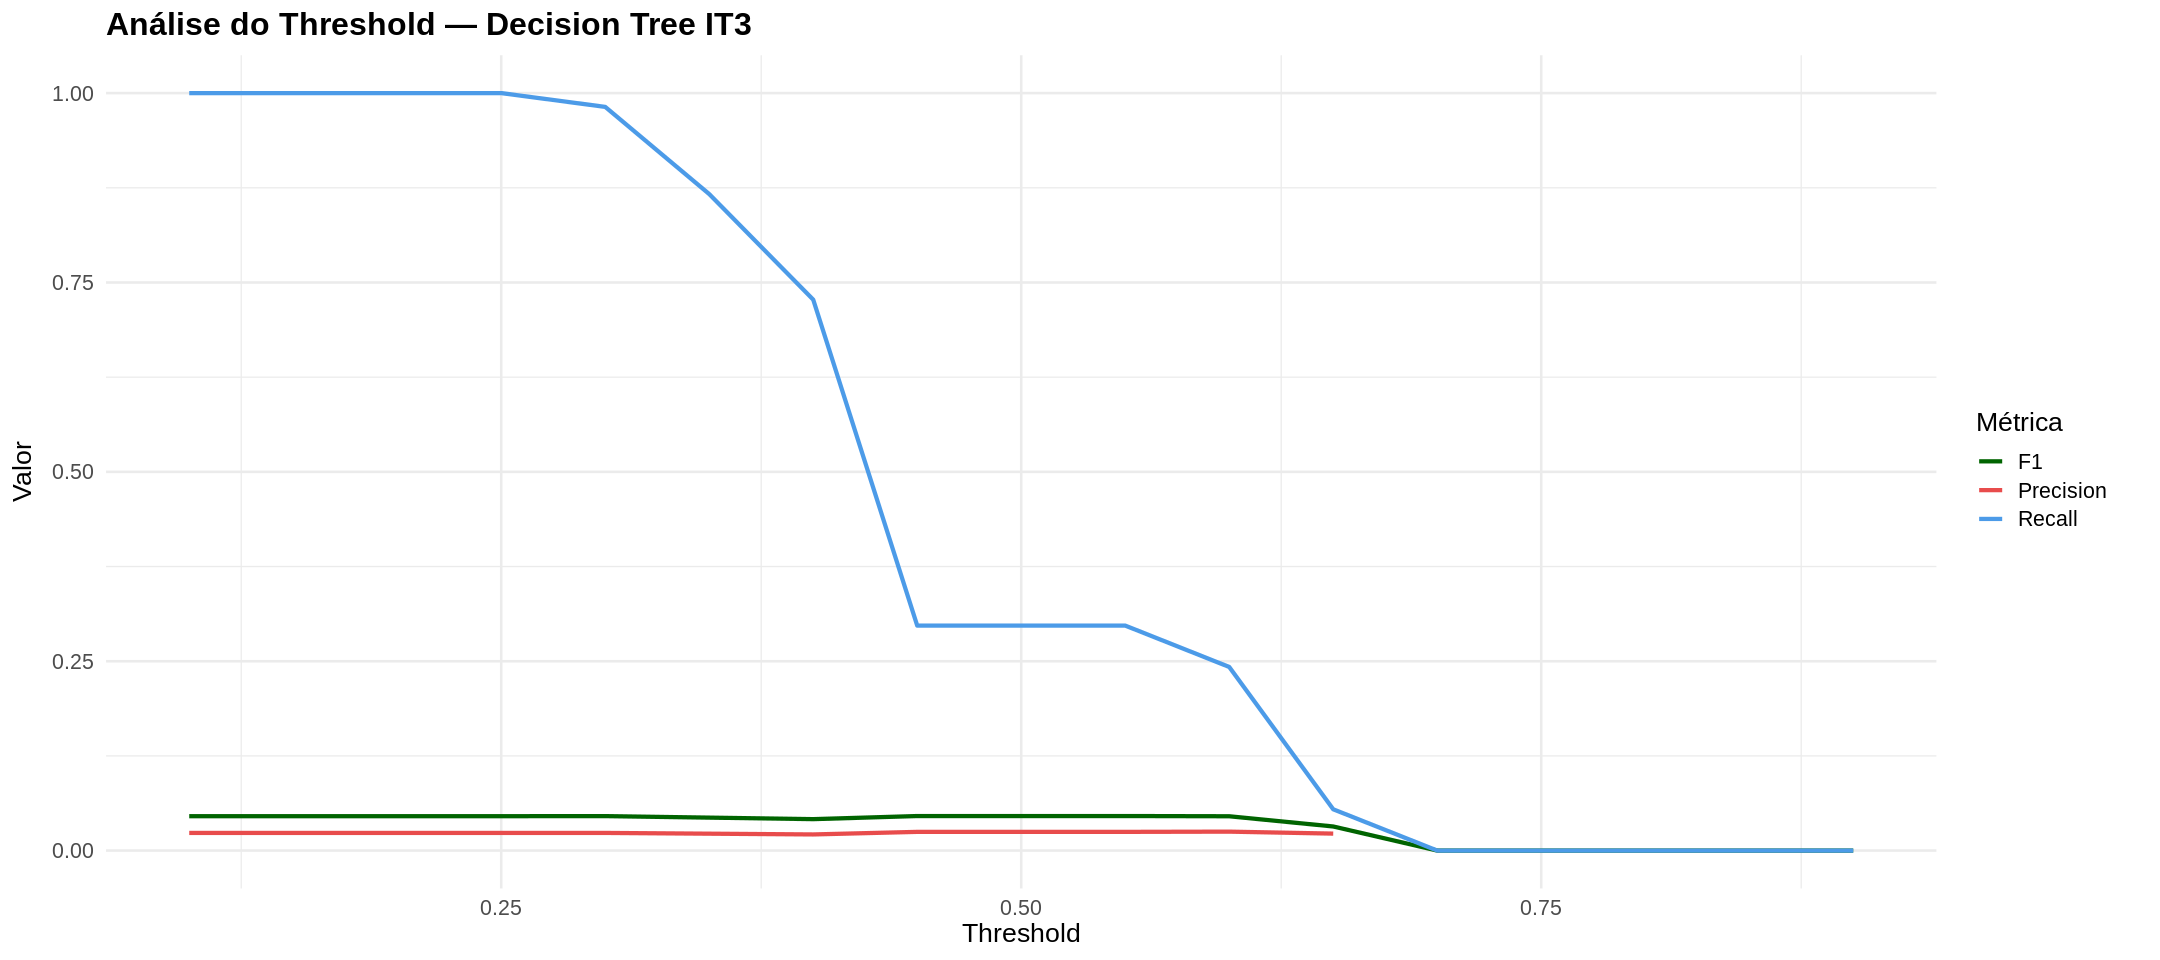

In [ ]:
thresholds           <- seq(0.1, 0.9, by = 0.05)
resultados_threshold <- data.frame()

for (t in thresholds) {
  pred_t <- factor(ifelse(prob_dt >= t, "Recomprou", "Nao_recomprou"),
                   levels = levels(teste_final$target_repurchase))
  cm_t   <- confusionMatrix(pred_t, teste_final$target_repurchase, positive = "Recomprou")
  prec   <- cm_t$byClass["Pos Pred Value"]
  rec    <- cm_t$byClass["Sensitivity"]
  f1_raw <- 2 * (prec * rec) / (prec + rec)
  resultados_threshold <- rbind(resultados_threshold, data.frame(
    threshold = t,
    Precision = round(prec, 4),
    Recall    = round(rec,  4),
    F1        = round(ifelse(is.na(f1_raw), 0, f1_raw), 4)
  ))
}

resultados_threshold %>%
  pivot_longer(cols = c(Precision, Recall, F1),
               names_to = "metrica", values_to = "valor") %>%
  ggplot(aes(x = threshold, y = valor, color = metrica)) +
  geom_line(linewidth = 1.2) +
  scale_color_manual(values = c("Precision" = "#E84C4C",
                                "Recall"    = "#4C9BE8",
                                "F1"        = "darkgreen")) +
  labs(title = "Análise do Threshold — Decision Tree IT3",
       x = "Threshold", y = "Valor", color = "Métrica") +
  theme_minimal(base_size = 16) +
  theme(plot.title = element_text(face = "bold"))

### 8.5 Distribuição de Probabilidades

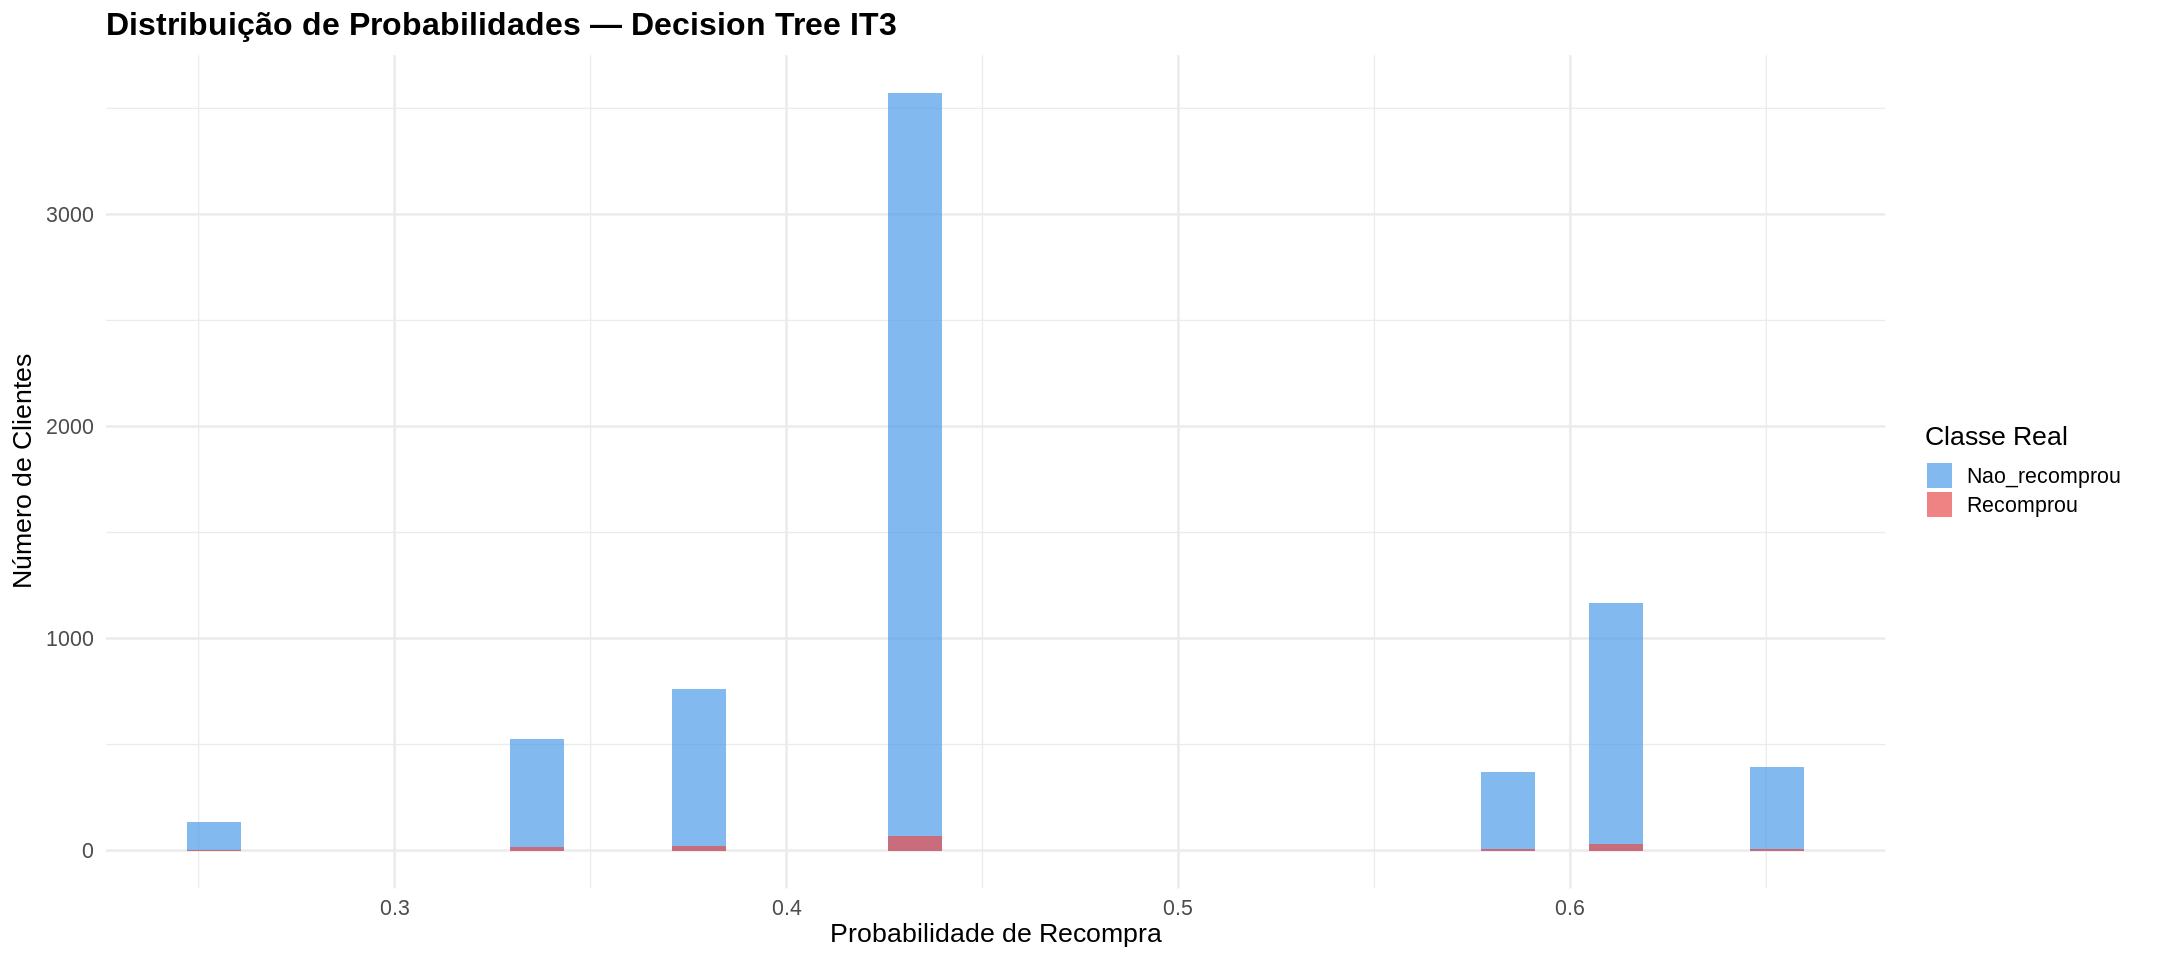

In [ ]:
prob_df <- data.frame(probabilidade = prob_dt, real = teste_final$target_repurchase)

ggplot(prob_df, aes(x = probabilidade, fill = real)) +
  geom_histogram(bins = 30, alpha = 0.7, position = "identity") +
  scale_fill_manual(values = c("Nao_recomprou" = "#4C9BE8", "Recomprou" = "#E84C4C")) +
  labs(title = "Distribuição de Probabilidades — Decision Tree IT3",
       x = "Probabilidade de Recompra", y = "Número de Clientes", fill = "Classe Real") +
  theme_minimal(base_size = 16) +
  theme(plot.title = element_text(face = "bold"))

## 9. Análise de Erros

### 9.1 Identificação de FP e FN

In [ ]:
erros_dt      <- teste_final
erros_dt$prob <- prob_dt
erros_dt$pred <- pred_dt
erros_dt$real <- teste_final$target_repurchase

fn_dt <- erros_dt[erros_dt$real == "Recomprou"    & erros_dt$pred == "Nao_recomprou", ]
fp_dt <- erros_dt[erros_dt$real == "Nao_recomprou" & erros_dt$pred == "Recomprou",    ]

cat("Falsos negativos:", nrow(fn_dt), "\n")
cat("Falsos positivos:", nrow(fp_dt), "\n")

Falsos negativos: 116 
Falsos positivos: 1933 


### 9.2 Perfil dos Erros

In [ ]:
perfil_erros <- data.frame(
  Grupo                   = c("Falsos Negativos", "Falsos Positivos"),
  recency_days            = c(round(mean(fn_dt$recency_days), 2),
                               round(mean(fp_dt$recency_days), 2)),
  total_orders            = c(round(mean(fn_dt$total_orders), 2),
                               round(mean(fp_dt$total_orders), 2)),
  total_spent             = c(round(mean(fn_dt$total_spent), 2),
                               round(mean(fp_dt$total_spent), 2)),
  avg_review_score        = c(round(mean(fn_dt$avg_review_score), 2),
                               round(mean(fp_dt$avg_review_score), 2)),
  avg_delivery_delay_days = c(round(mean(fn_dt$avg_delivery_delay_days), 2),
                               round(mean(fp_dt$avg_delivery_delay_days), 2)),
  avg_items_per_order     = c(round(mean(fn_dt$avg_items_per_order), 2),
                               round(mean(fp_dt$avg_items_per_order), 2))
)

kable(perfil_erros, caption = "Perfil dos Erros — Decision Tree IT3")



Table: Perfil dos Erros — Decision Tree IT3

|Grupo            | recency_days| total_orders| total_spent| avg_review_score| avg_delivery_delay_days| avg_items_per_order|
|:----------------|------------:|------------:|-----------:|----------------:|-----------------------:|-------------------:|
|Falsos Negativos |       124.38|         1.10|      195.40|             4.43|                  -12.74|                1.21|
|Falsos Positivos |        50.37|         1.03|      114.23|             4.36|                  -12.39|                1.10|

## 10. Aplicação Prática

In [ ]:
prob_aplicacao <- data.frame(
  probabilidade = prob_dt, real = teste_final$target_repurchase
) %>% arrange(desc(probabilidade))

alta_prob <- prob_aplicacao[prob_aplicacao$probabilidade > 0.7, ]
cat("Clientes com probabilidade > 0.7:", nrow(alta_prob), "\n")
cat("  Recompradores reais:  ", sum(alta_prob$real == "Recomprou"), "\n")
cat("  Precision nesse grupo:", round(mean(alta_prob$real == "Recomprou") * 100, 1), "%\n\n")

media_prob <- prob_aplicacao[prob_aplicacao$probabilidade > 0.5, ]
cat("Clientes com probabilidade > 0.5:", nrow(media_prob), "\n")
cat("  Recompradores reais:  ", sum(media_prob$real == "Recomprou"), "\n")
cat("  Precision nesse grupo:", round(mean(media_prob$real == "Recomprou") * 100, 1), "%\n")

Clientes com probabilidade > 0.7: 0 
  Recompradores reais:   0 
  Precision nesse grupo: NaN %

Clientes com probabilidade > 0.5: 1982 
  Recompradores reais:   49 
  Precision nesse grupo: 2.5 %


## 11. Comparação Consolidada — IT1 vs IT2 vs IT3

In [ ]:
it1_ok <- file.exists("resultados_it1.rds")
it2_ok <- file.exists("resultados_it2.rds")

if (!it1_ok) cat("AVISO: resultados_it1.rds não encontrado. Execute IT1 primeiro.\n")
if (!it2_ok) cat("AVISO: resultados_it2.rds não encontrado. Execute IT2 primeiro.\n")

if (it1_ok && it2_ok) {
  r1 <- readRDS("resultados_it1.rds")
  r2 <- readRDS("resultados_it2.rds")

  tabela_consolidada <- data.frame(
    Iteracao  = c("IT1 DT (RFM)", "IT1 RF (RFM)",
                  "IT2 DT (RFM+Exp)", "IT2 RF (RFM+Exp)",
                  "IT3 DT (RFM+Exp+Items)", "IT3 RF (RFM+Exp+Items)"),
    Recall    = c(r1$dt_recall, r1$rf_recall,
                  r2$dt_recall, r2$rf_recall,
                  round(recall_dt, 4), round(recall_rf, 4)),
    Precision = c(r1$dt_precision, r1$rf_precision,
                  r2$dt_precision, r2$rf_precision,
                  round(precision_dt, 4), round(precision_rf, 4)),
    F1_Score  = c(r1$dt_f1, r1$rf_f1,
                  r2$dt_f1, r2$rf_f1,
                  round(f1_dt, 4), round(f1_rf, 4)),
    ROC_AUC   = c(r1$dt_rocauc, r1$rf_rocauc,
                  r2$dt_rocauc, r2$rf_rocauc,
                  auc_dt_roc, auc_rf_roc),
    PR_AUC    = c(r1$dt_prauc, r1$rf_prauc,
                  r2$dt_prauc, r2$rf_prauc,
                  auc_dt_pr, auc_rf_pr)
  )

  kable(tabela_consolidada,
        caption = "Comparação Consolidada — IT1, IT2, IT3",
        digits  = 4)

  tabela_consolidada %>%
    ggplot(aes(x = Iteracao, y = PR_AUC, fill = Iteracao)) +
    geom_col(alpha = 0.8) +
    geom_hline(yintercept = baseline_pr, linetype = "dashed", color = "gray50") +
    annotate("text", x = 1, y = baseline_pr + 0.001,
             label = paste0("Baseline = ", round(baseline_pr * 100, 1), "%"),
             color = "gray50", hjust = 0, size = 4) +
    geom_text(aes(label = round(PR_AUC, 4)), vjust = -0.4, size = 4) +
    scale_fill_brewer(palette = "Set2") +
    labs(title = "PR-AUC por Iteração e Modelo",
         x = NULL, y = "PR-AUC") +
    theme_minimal(base_size = 14) +
    theme(plot.title = element_text(face = "bold"),
          legend.position = "none",
          axis.text.x = element_text(angle = 30, hjust = 1))
}

AVISO: resultados_it1.rds não encontrado. Execute IT1 primeiro.
AVISO: resultados_it2.rds não encontrado. Execute IT2 primeiro.


## 12. Salvar Resultados

In [ ]:
resultados_it3 <- list(
  dt_accuracy  = round(accuracy_dt,  4),
  dt_precision = round(precision_dt, 4),
  dt_recall    = round(recall_dt,    4),
  dt_f1        = round(f1_dt,        4),
  dt_rocauc    = auc_dt_roc,
  dt_prauc     = auc_dt_pr,
  rf_accuracy  = round(accuracy_rf,  4),
  rf_precision = round(precision_rf, 4),
  rf_recall    = round(recall_rf,    4),
  rf_f1        = round(f1_rf,        4),
  rf_rocauc    = auc_rf_roc,
  rf_prauc     = auc_rf_pr
)

saveRDS(resultados_it3, "resultados_it3.rds")
cat("\nResultados salvos em 'resultados_it3.rds'\n")


Resultados salvos em 'resultados_it3.rds'
